In [ ]:
# CELL 1: Setup & Unzip
import zipfile, os, time
from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH   = '/content/drive/MyDrive/dataverse_files.zip'
EXTRACT_TO = '/content/data/telecom/'
os.makedirs(EXTRACT_TO, exist_ok=True)

existing = os.listdir(EXTRACT_TO)
if len(existing) < 50:
    print('Unzipping...')
    t0 = time.time()
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_TO)
        files = z.namelist()
    print(f'Done in {time.time()-t0:.0f}s — {len(files)} files extracted')
else:
    print(f'Already extracted — {len(existing)} files found')

DATA_DIR   = os.path.join(EXTRACT_TO, 'dataverse_files/') # Corrected path to data files
OUTPUT_DIR = '/content/drive/MyDrive/milan_outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'DATA_DIR:   {DATA_DIR}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Unzipping...
Done in 168s — 53 files extracted
DATA_DIR:   /content/data/telecom/dataverse_files/
OUTPUT_DIR: /content/drive/MyDrive/milan_outputs/


In [ ]:
print(f'Listing contents of DATA_DIR: {DATA_DIR}')
!ls -F {DATA_DIR}

Listing contents of DATA_DIR: /content/data/telecom/
dataverse_files/


In [ ]:
# CELL 2: Imports
!pip install -q statsmodels pmdarima memory_profiler

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings, time, psutil, gc, glob
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print('All imports done!')

Device: cuda
All imports done!


In [ ]:
# CELL 3: Task 1 - Data Handling & Memory Management
import glob
import os # Added import os here
import pandas as pd # Added import pandas as pd here
import gc # Added import gc here
import psutil # Added import psutil here
import time # Added import time here

# Ensure base paths are defined for this cell's execution
EXTRACT_TO = '/content/data/telecom/'
DATA_DIR   = os.path.join(EXTRACT_TO, 'dataverse_files/') # Corrected path to data files

def get_ram_mb():
    return psutil.Process(os.getpid()).memory_info().rss / (1024**2)

def get_df_mb(df):
    return df.memory_usage(deep=True).sum() / (1024**2)

COL_NAMES = ['square_id','time_interval','country_code',
             'sms_in','sms_out','call_in','call_out','internet_traffic']

# Demonstrate memory optimization on 1 file
sample_file = sorted(glob.glob(os.path.join(DATA_DIR, '*.txt')))[0]
print(f'Sample file: {os.path.basename(sample_file)}')

# BEFORE optimization (default dtypes)
df_before = pd.read_csv(sample_file, sep='\t', header=None, names=COL_NAMES,
                        usecols=['square_id','time_interval','internet_traffic'])
mem_before = get_df_mb(df_before)
print(f'\nMemory BEFORE optimization (1 file): {mem_before:.2f} MB')
print(f'  square_id dtype:        {df_before["square_id"].dtype}')
print(f'  internet_traffic dtype: {df_before["internet_traffic"].dtype}')
del df_before; gc.collect()

# AFTER optimization (reduced dtypes)
df_after = pd.read_csv(sample_file, sep='\t', header=None, names=COL_NAMES,
                       usecols=['square_id','time_interval','internet_traffic'],
                       dtype={'square_id':'int32','time_interval':'int64','internet_traffic':'float32'})
mem_after = get_df_mb(df_after)
print(f'\nMemory AFTER optimization (1 file):  {mem_after:.2f} MB')
print(f'  square_id dtype:        {df_after["square_id"].dtype}')
print(f'  internet_traffic dtype: {df_after["internet_traffic"].dtype}')
print(f'\nMemory reduction: {((mem_before-mem_after)/mem_before)*100:.1f}%')
del df_after; gc.collect()

# Load full dataset
print('\nLoading full dataset...')
ram_start = get_ram_mb()
t_start   = time.time()

all_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.txt')))
print(f'Found {len(all_files)} files')

chunks = []
for i, fp in enumerate(all_files):
    df_chunk = pd.read_csv(fp, sep='\t', header=None, names=COL_NAMES,
                           usecols=['square_id','time_interval','internet_traffic'],
                           dtype={'square_id':'int32','time_interval':'int64','internet_traffic':'float32'})
    chunks.append(df_chunk)
    if (i+1) % 10 == 0:
        print(f'  Loaded {i+1}/{len(all_files)} files | RAM: {get_ram_mb():.0f} MB')

df_raw = pd.concat(chunks, ignore_index=True)
del chunks; gc.collect()

# Convert millisecond timestamp to datetime
df_raw['timestamp'] = pd.to_datetime(df_raw['time_interval'], unit='ms')
df_raw.drop(columns=['time_interval'], inplace=True)
df_raw['internet_traffic'] = df_raw['internet_traffic'].fillna(0).astype('float32')

ram_end = get_ram_mb()
t_end   = time.time()

print(f'\n=== Dataset Loaded ===')
print(f'Shape:         {df_raw.shape}')
print(f'DataFrame MB:  {get_df_mb(df_raw):.1f} MB')
print(f'RAM used:      {ram_end - ram_start:.0f} MB')
print(f'Load time:     {t_end - t_start:.1f}s')
print(f'Date range:    {df_raw.timestamp.min()} \u2192 {df_raw.timestamp.max()}')
print(f'Unique areas:  {df_raw.square_id.nunique()}')
df_raw.head()

Sample file: sms-call-internet-mi-2013-11-01.txt

Memory BEFORE optimization (1 file): 110.84 MB
  square_id dtype:        int64
  internet_traffic dtype: float64

Memory AFTER optimization (1 file):  73.89 MB
  square_id dtype:        int32
  internet_traffic dtype: float32

Memory reduction: 33.3%

Loading full dataset...
Found 52 files
  Loaded 10/52 files | RAM: 1043 MB
  Loaded 20/52 files | RAM: 1888 MB
  Loaded 30/52 files | RAM: 2675 MB
  Loaded 40/52 files | RAM: 3479 MB
  Loaded 50/52 files | RAM: 4294 MB

=== Dataset Loaded ===
Shape:         (273595010, 3)
DataFrame MB:  4174.7 MB
RAM used:      5540 MB
Load time:     224.6s
Date range:    2013-10-31 23:00:00 → 2013-12-22 22:50:00
Unique areas:  10000


,square_id,internet_traffic,timestamp
0,1,0.000000,2013-10-31 23:00:00
1,1,11.028366,2013-10-31 23:00:00
2,1,0.000000,2013-10-31 23:10:00
3,1,0.026137,2013-10-31 23:10:00
4,1,11.100964,2013-10-31 23:10:00


In [ ]:
# CELL 4: Save as Parquet
import os

# Ensure OUTPUT_DIR is defined for this cell's execution
OUTPUT_DIR = '/content/drive/MyDrive/milan_outputs/'

parquet_path = os.path.join(OUTPUT_DIR, 'milan_telecom.parquet')
df_raw.to_parquet(parquet_path, index=False)
parquet_mb = os.path.getsize(parquet_path) / (1024**2)
print(f'Saved Parquet: {parquet_path}')
print(f'Parquet size:  {parquet_mb:.1f} MB (vs ~5000 MB raw TXT)')
print(f'Compression ratio: {5000/parquet_mb:.1f}x smaller')

Saved Parquet: /content/drive/MyDrive/milan_outputs/milan_telecom.parquet
Parquet size:  781.2 MB (vs ~5000 MB raw TXT)
Compression ratio: 6.4x smaller


Area with highest traffic: Square ID 5161 (11437732)
Area 4159 total: 2298216
Area 4556 total: 4190367


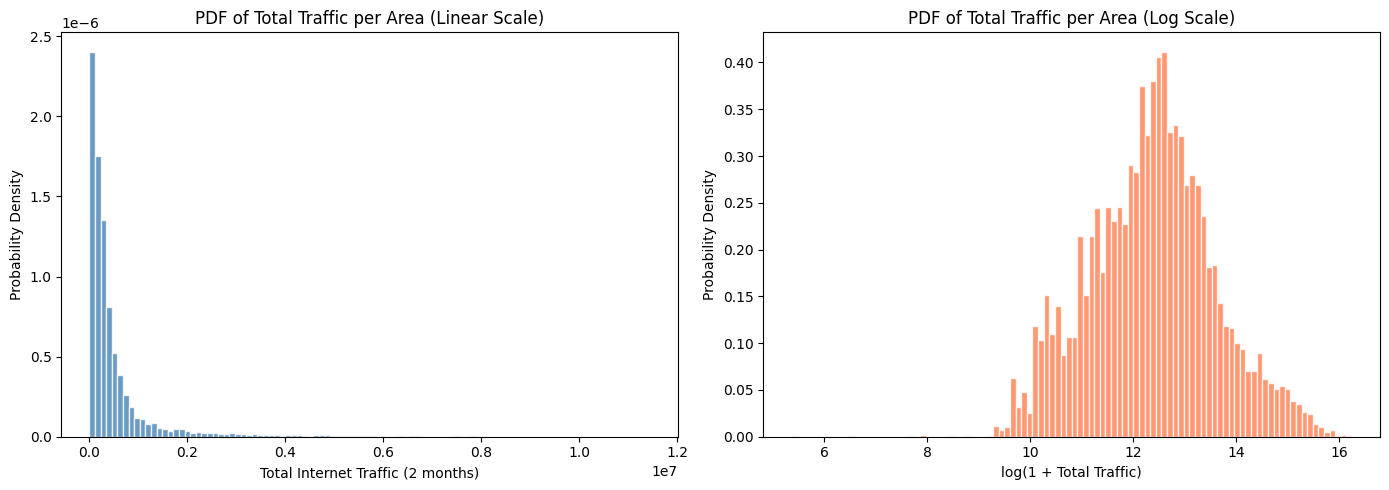


Interpretation: The distribution is heavily right-skewed (log-normal like), meaning most areas have low traffic while a few hotspots generate the majority of network activity.


In [ ]:
# CELL 5: Task 2 - Exploratory Data Analysis (Part 1)
import matplotlib.pyplot as plt # Added import for plotting
import numpy as np # Added import for numerical operations
import os # Ensure os is imported for path operations

# Total traffic per area
total_per_area = df_raw.groupby('square_id')['internet_traffic'].sum()
highest_area   = int(total_per_area.idxmax())
print(f'Area with highest traffic: Square ID {highest_area} ({total_per_area[highest_area]:.0f})')
print(f'Area 4159 total: {total_per_area[4159]:.0f}')
print(f'Area 4556 total: {total_per_area[4556]:.0f}')

AREAS = {
    f'Area {highest_area} (Highest)': highest_area,
    'Area 4159': 4159,
    'Area 4556': 4556
}
COLORS = ['steelblue', 'coral', 'green']

# PDF Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(total_per_area, bins=100, density=True, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Total Internet Traffic (2 months)')
axes[0].set_ylabel('Probability Density')
axes[0].set_title('PDF of Total Traffic per Area (Linear Scale)')
axes[1].hist(np.log1p(total_per_area), bins=100, density=True, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('log(1 + Total Traffic)')
axes[1].set_ylabel('Probability Density')
axes[1].set_title('PDF of Total Traffic per Area (Log Scale)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'task2_1_pdf.png'), bbox_inches='tight')
plt.show()
print('\nInterpretation: The distribution is heavily right-skewed (log-normal like), meaning most areas have low traffic while a few hotspots generate the majority of network activity.')

In [ ]:
# CELL 6: Task 2 - Build time series
def get_series(df, area_id):
    s = df[df['square_id']==area_id][['timestamp','internet_traffic']]\
          .sort_values('timestamp').set_index('timestamp')['internet_traffic']
    return s.resample('10min').sum().fillna(0)

series = {name: get_series(df_raw, aid) for name, aid in AREAS.items()}
print('Time series built:')
for name, s in series.items():
    print(f'  {name}: {len(s)} steps | {s.index.min().date()} → {s.index.max().date()}')

Time series built:
  Area 5161 (Highest): 7488 steps | 2013-10-31 → 2013-12-22
  Area 4159: 7488 steps | 2013-10-31 → 2013-12-22
  Area 4556: 7488 steps | 2013-10-31 → 2013-12-22


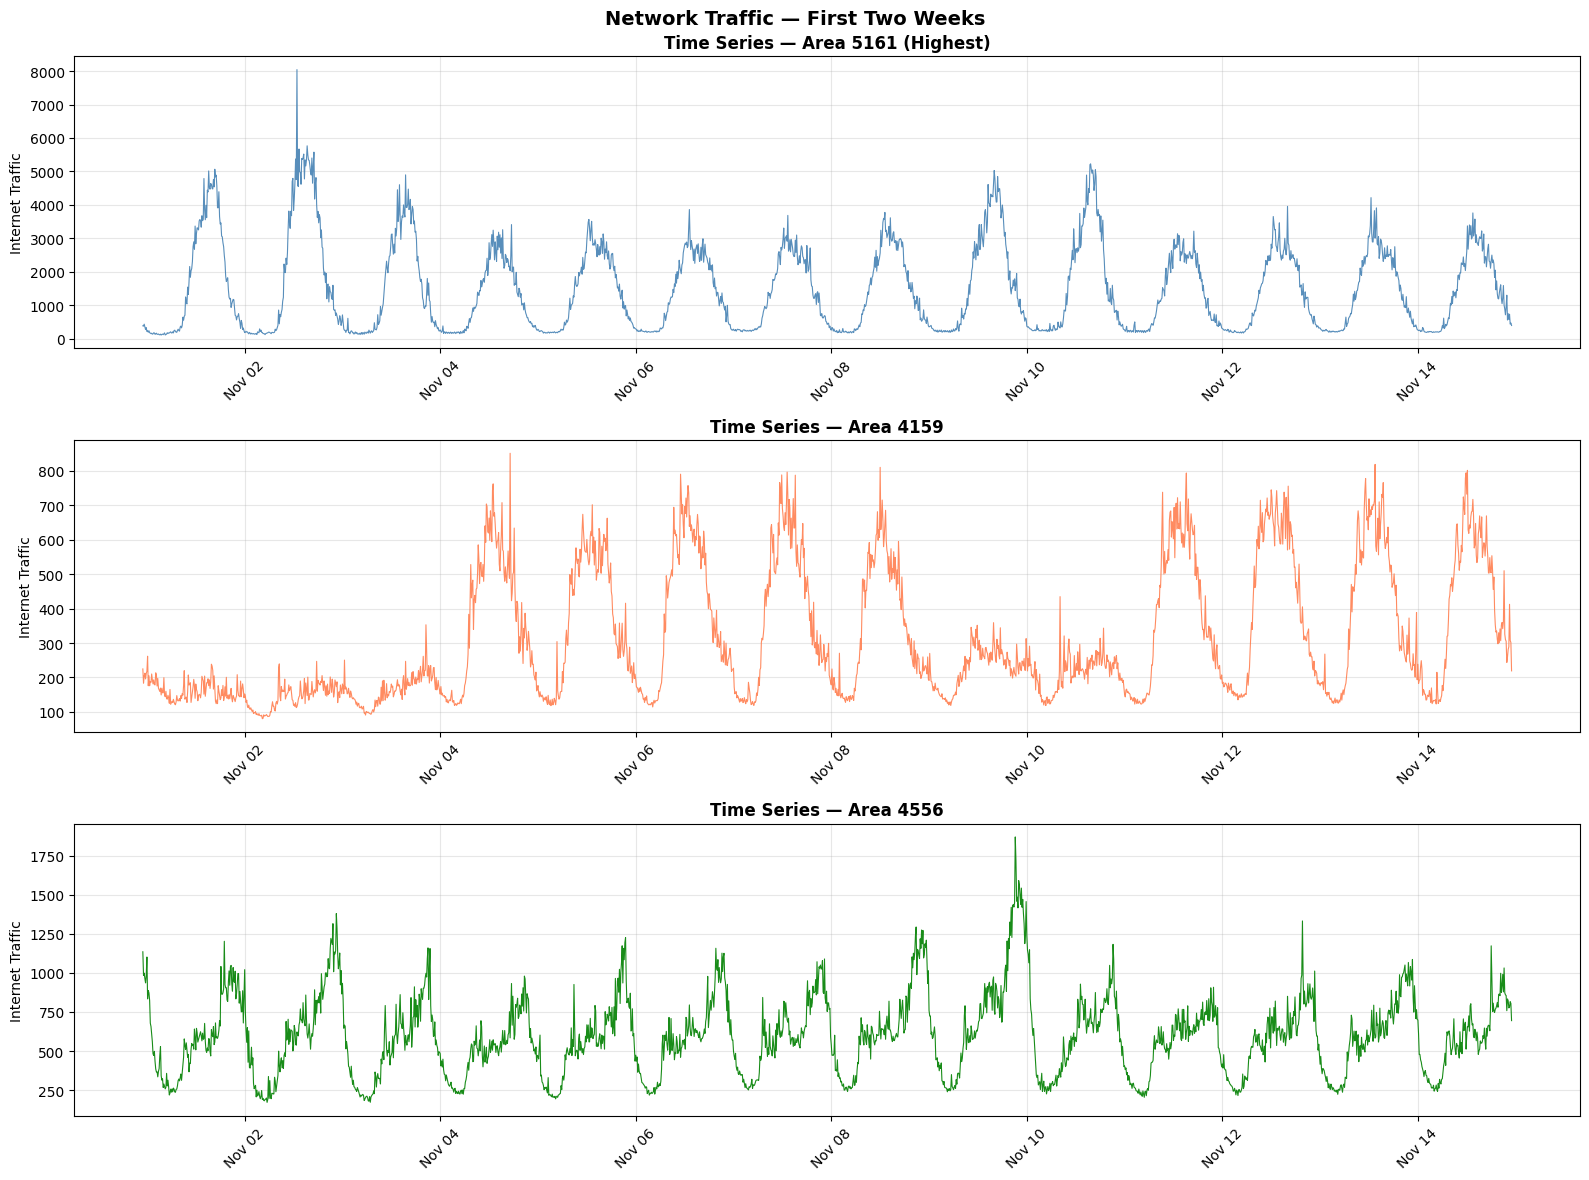

In [ ]:
# CELL 7: Task 2 - Time Series First 2 Weeks
import matplotlib.dates as mdates # Added import for mdates

two_weeks_end = df_raw['timestamp'].min() + pd.Timedelta(weeks=2)
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=False)
for ax, (name, s), color in zip(axes, series.items(), COLORS):
    s2w = s[s.index <= two_weeks_end]
    ax.plot(s2w.index, s2w.values, color=color, linewidth=0.8, alpha=0.9)
    ax.set_title(f'Time Series — {name}', fontweight='bold')
    ax.set_ylabel('Internet Traffic')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
plt.suptitle('Network Traffic — First Two Weeks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'task2_2_timeseries.png'), bbox_inches='tight')
plt.show()


--- ADF Test: Area 5161 (Highest) ---
  ADF Statistic: -18.6241
  p-value:       0.000000
  Critical 1%:  -3.4312
  Critical 5%:  -2.8619
  Critical 10%:  -2.5670
  Result: STATIONARY

--- ADF Test: Area 4159 ---
  ADF Statistic: -13.8426
  p-value:       0.000000
  Critical 1%:  -3.4312
  Critical 5%:  -2.8619
  Critical 10%:  -2.5670
  Result: STATIONARY

--- ADF Test: Area 4556 ---
  ADF Statistic: -15.7190
  p-value:       0.000000
  Critical 1%:  -3.4312
  Critical 5%:  -2.8619
  Critical 10%:  -2.5670
  Result: STATIONARY


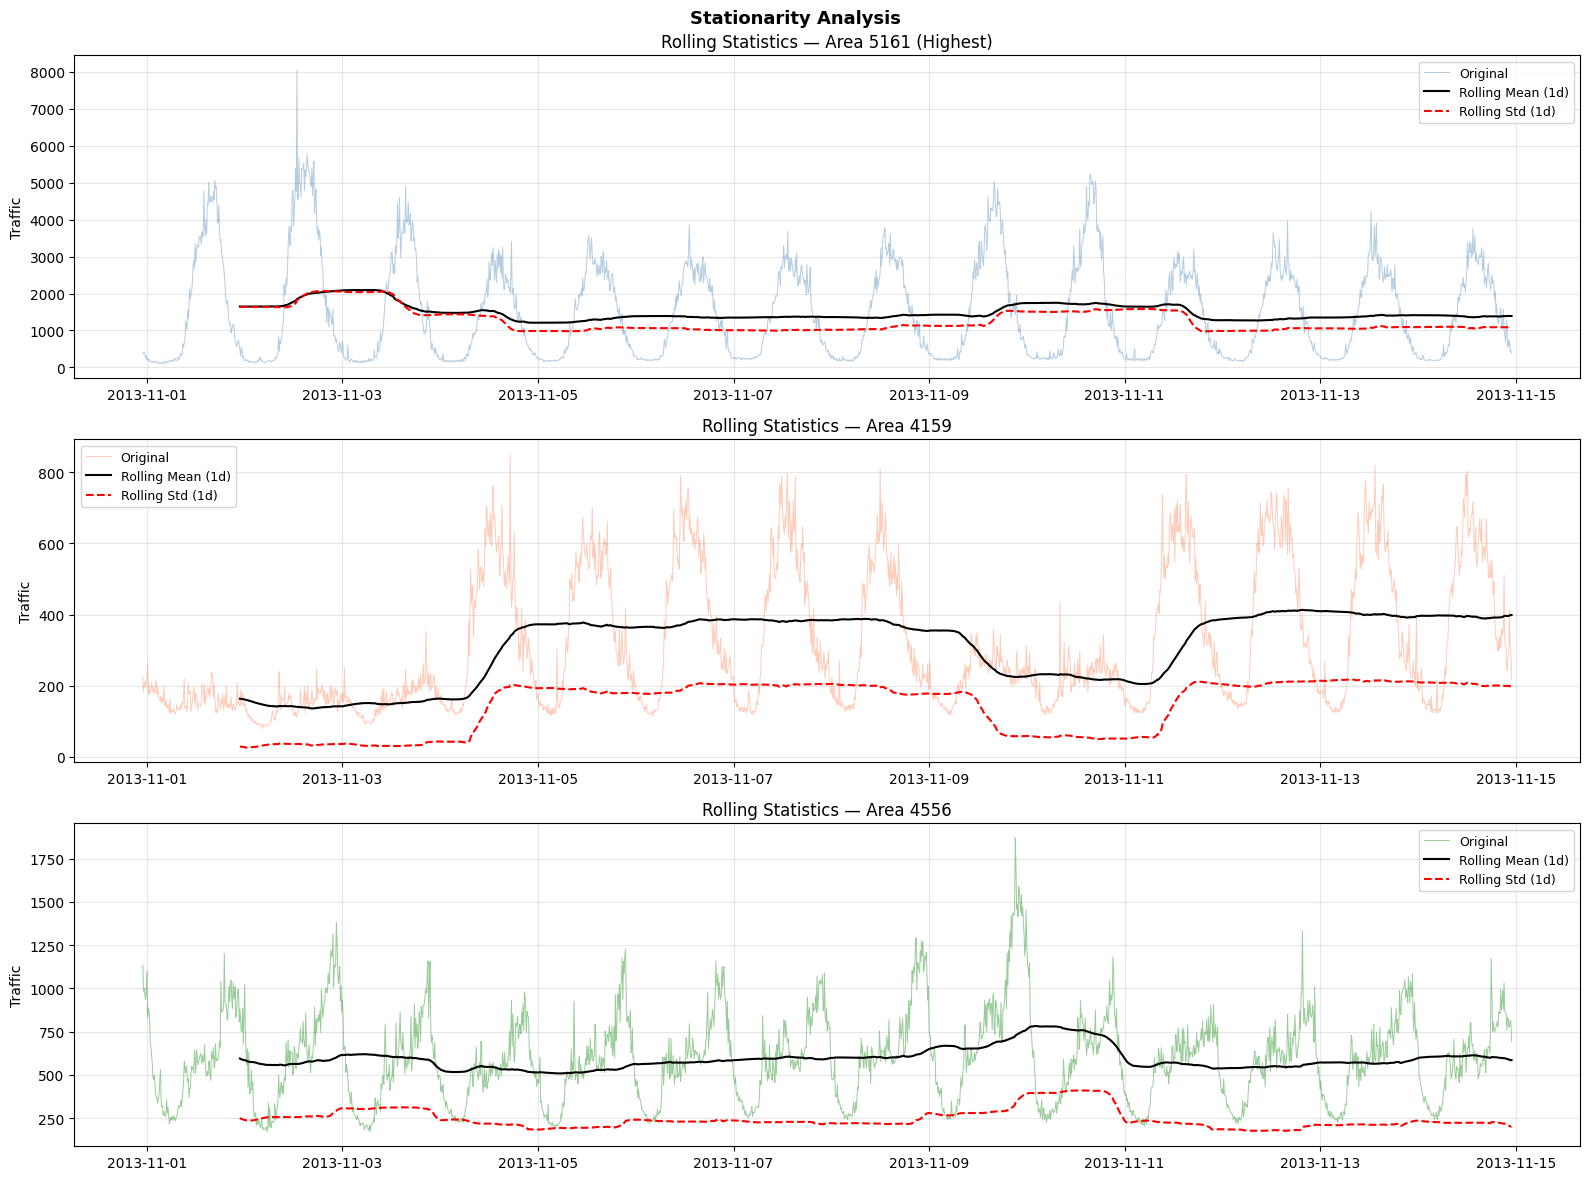

In [ ]:
# CELL 8: Task 2 - Stationarity Analysis
from statsmodels.tsa.stattools import adfuller # Added import for adfuller

PERIOD = 144  # 1 day = 144 x 10-min intervals

def adf_test(s, name):
    result = adfuller(s.dropna(), autolag='AIC')
    print(f'\n--- ADF Test: {name} ---')
    print(f'  ADF Statistic: {result[0]:.4f}')
    print(f'  p-value:       {result[1]:.6f}')
    for k, v in result[4].items():
        print(f'  Critical {k}:  {v:.4f}')
    status = 'STATIONARY' if result[1] < 0.05 else 'NON-STATIONARY'
    print(f'  Result: {status}')
    return result

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
for ax, (name, s), color in zip(axes, series.items(), COLORS):
    s2w = s[s.index <= two_weeks_end]
    rm  = s2w.rolling(PERIOD).mean()
    rs  = s2w.rolling(PERIOD).std()
    ax.plot(s2w.index, s2w.values, color=color, alpha=0.4, linewidth=0.7, label='Original')
    ax.plot(rm.index, rm.values, color='black', linewidth=1.5, label='Rolling Mean (1d)')
    ax.plot(rs.index, rs.values, color='red', linewidth=1.5, linestyle='--', label='Rolling Std (1d)')
    ax.set_title(f'Rolling Statistics — {name}')
    ax.set_ylabel('Traffic')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    adf_test(s, name)
plt.suptitle('Stationarity Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'task2_3_stationarity.png'), bbox_inches='tight')
plt.show()

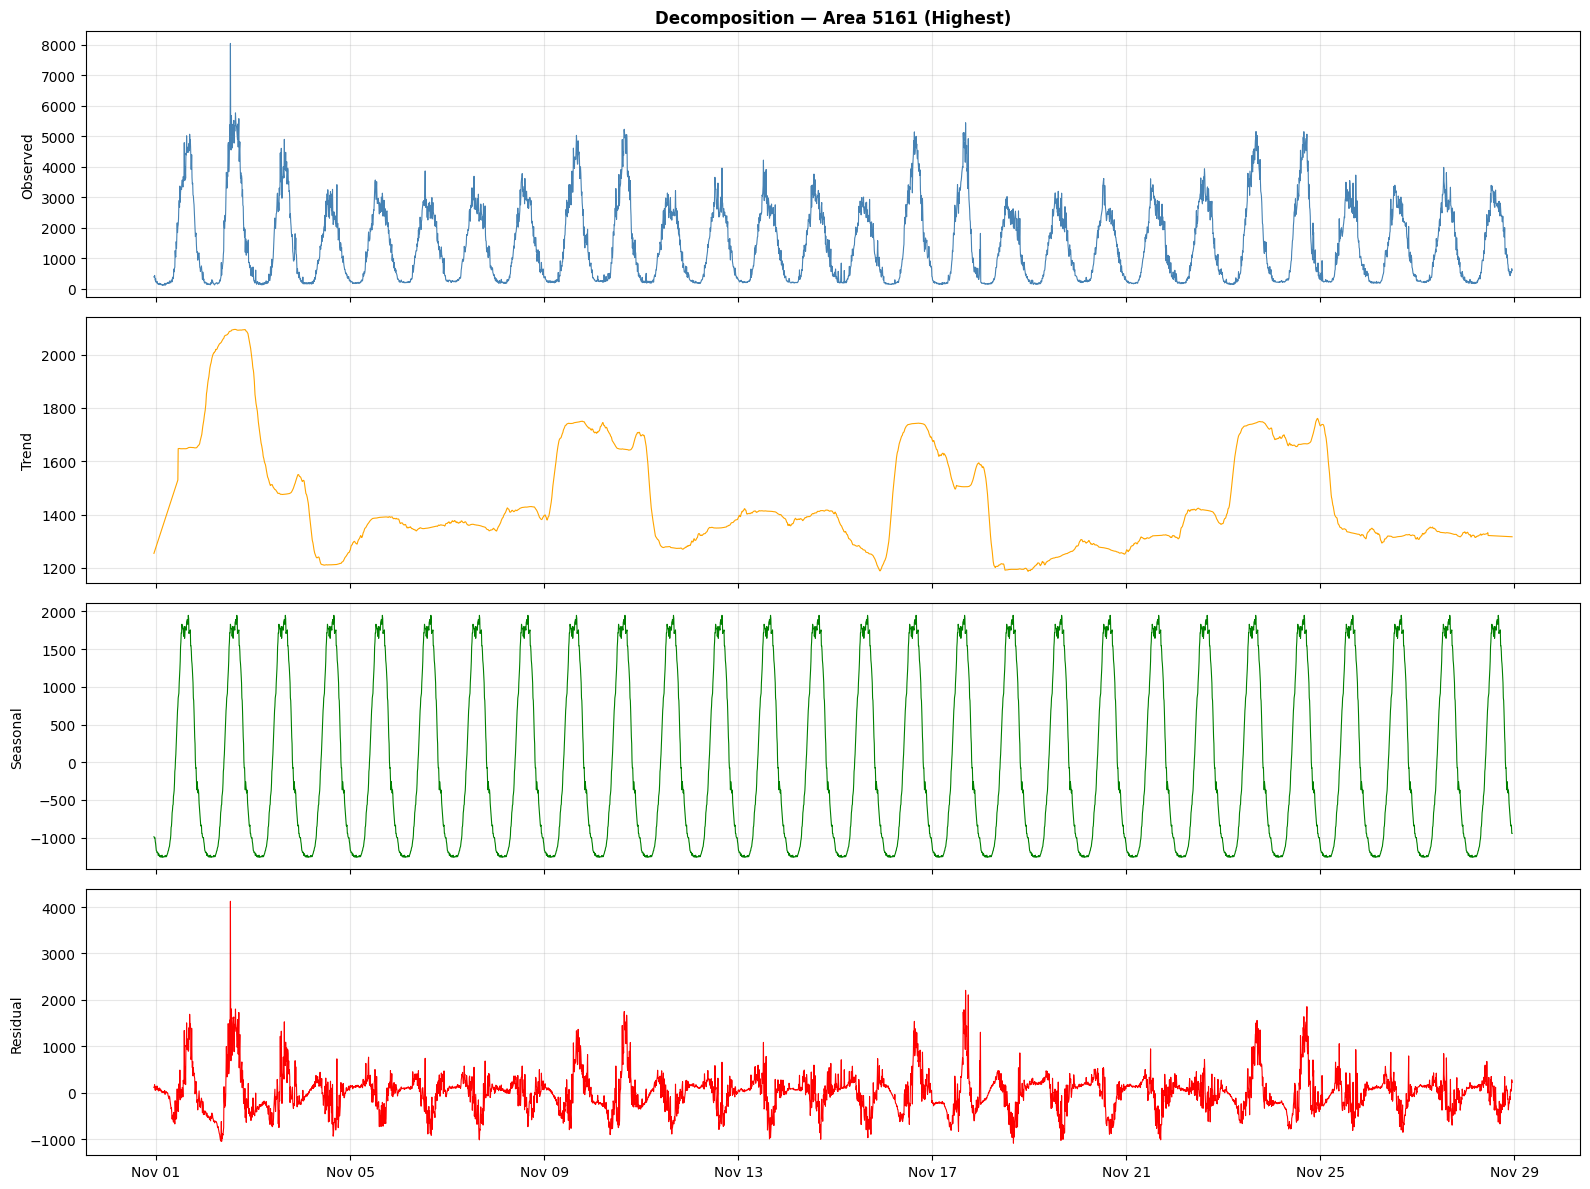

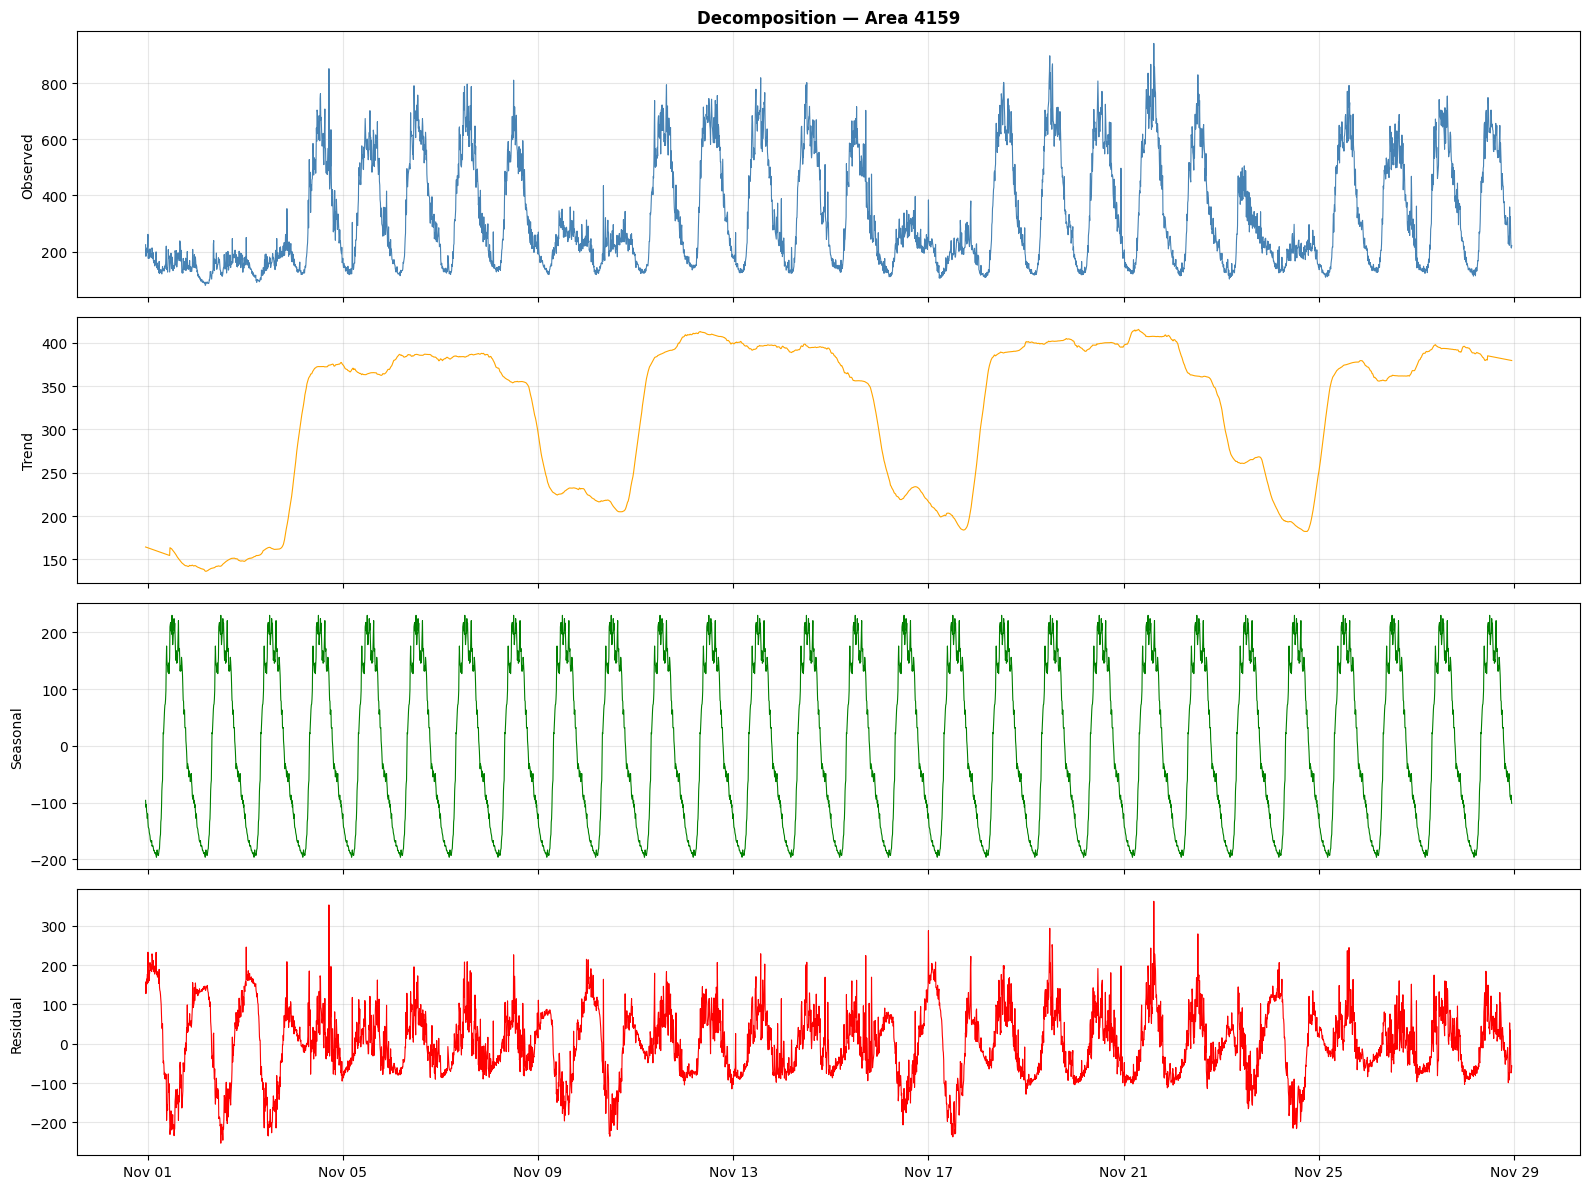

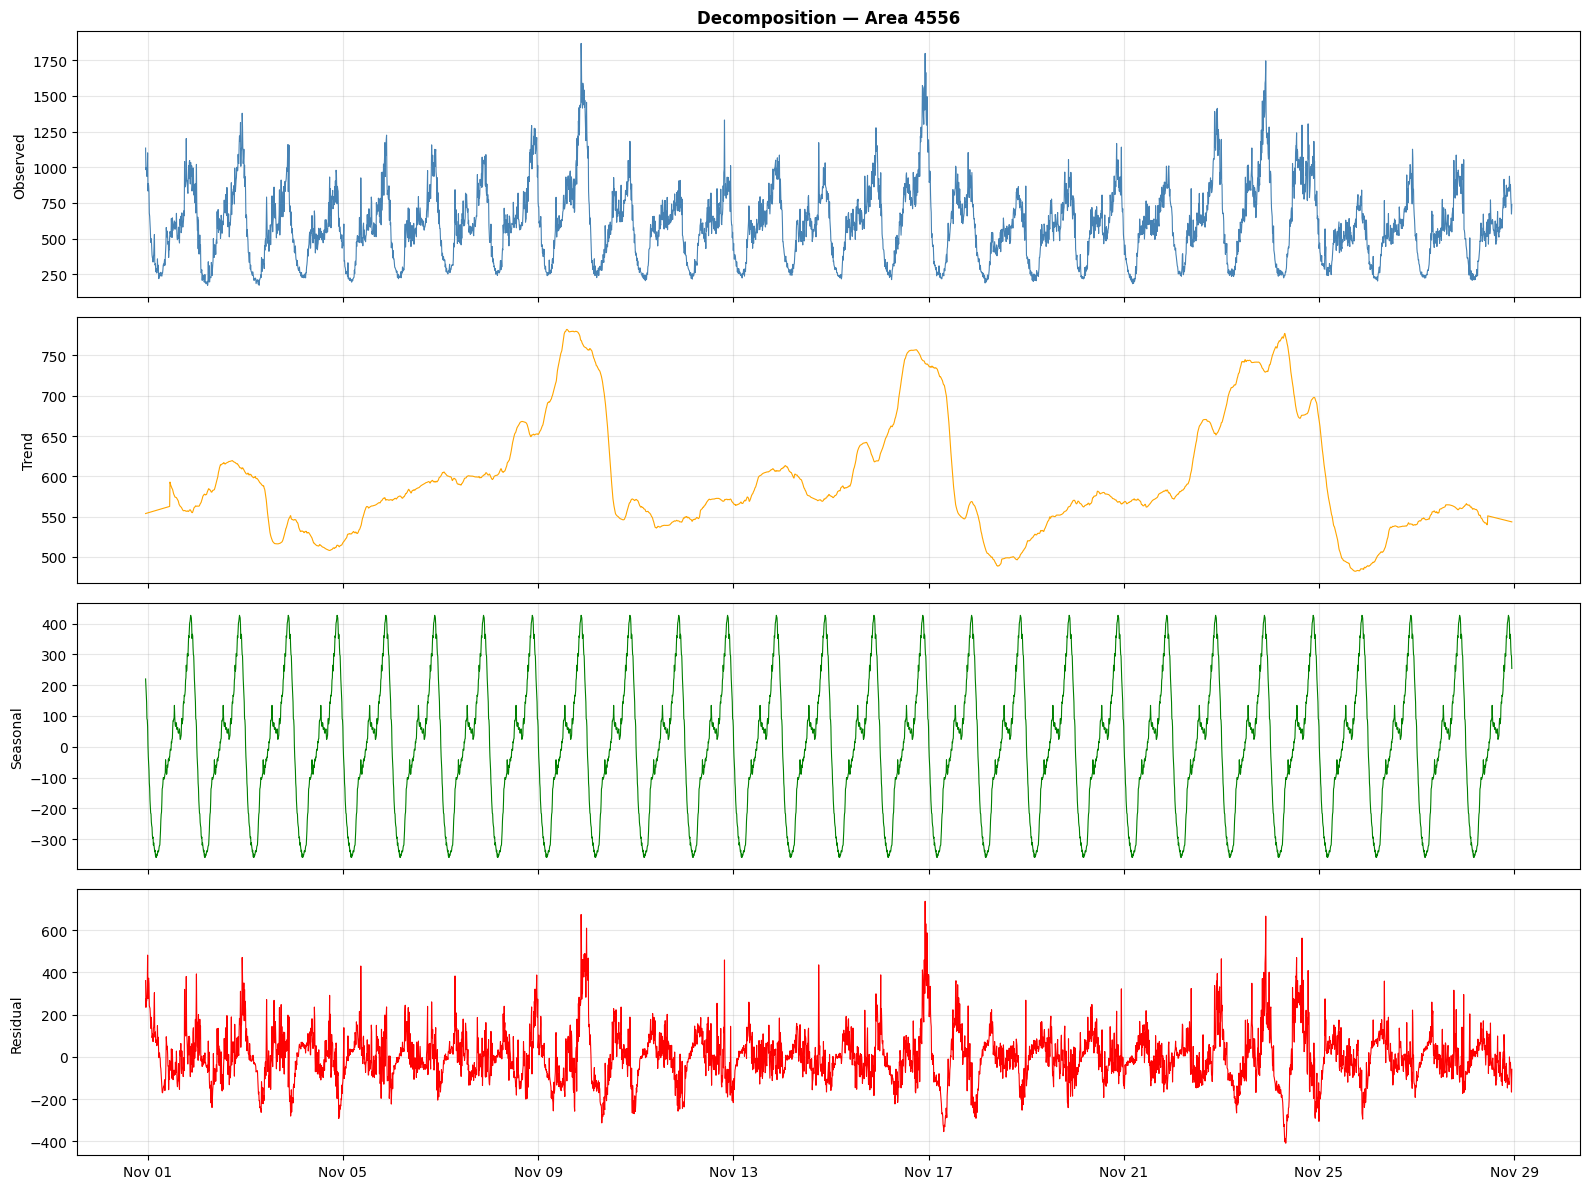

In [ ]:
# CELL 9: Task 2 - Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose # Added import for seasonal_decompose

for name, s in series.items():
    s4w = s.iloc[:4*7*PERIOD].copy()
    s4w = s4w.replace(0, s4w[s4w>0].min() * 0.01 if (s4w>0).any() else 0.001)
    decomp = seasonal_decompose(s4w, model='additive', period=PERIOD, extrapolate_trend='freq')
    fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
    for ax, data, label, c in zip(axes,
        [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid],
        ['Observed','Trend','Seasonal','Residual'],
        ['steelblue','orange','green','red']):
        ax.plot(data.index, data.values, color=c, linewidth=0.8)
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    axes[0].set_title(f'Decomposition — {name}', fontweight='bold')
    plt.tight_layout()
    safe = name.replace(' ','_').replace('(','').replace(')','')
    plt.savefig(os.path.join(OUTPUT_DIR, f'task2_4_decomp_{safe}.png'), bbox_inches='tight')
    plt.show()

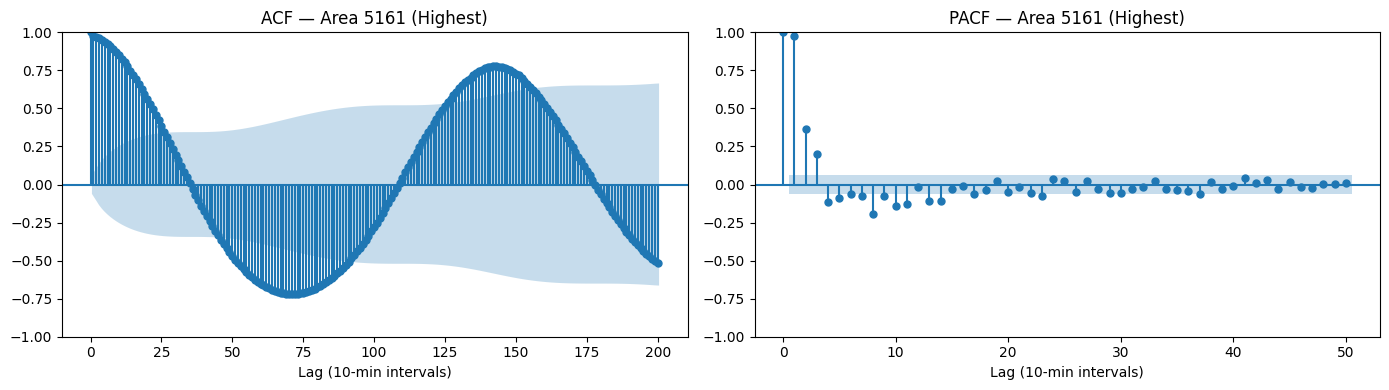

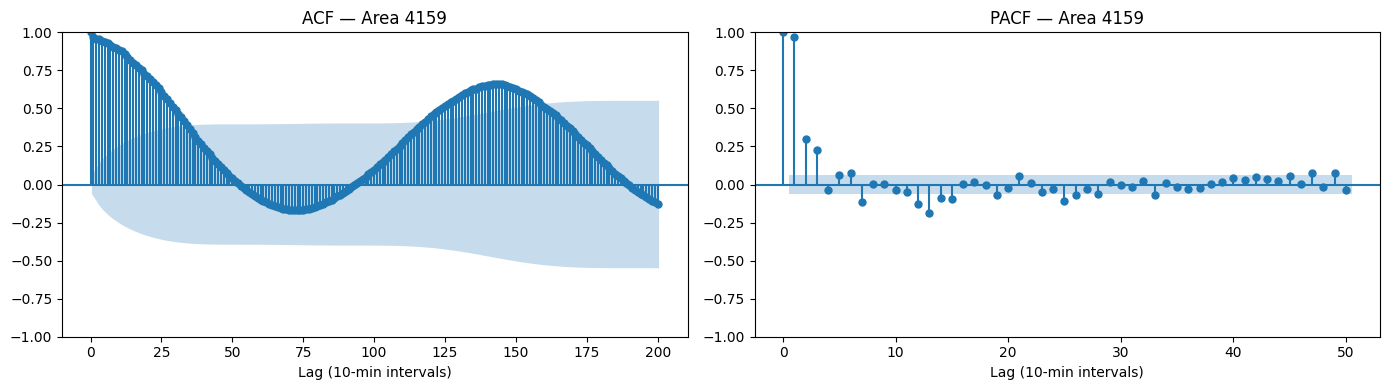

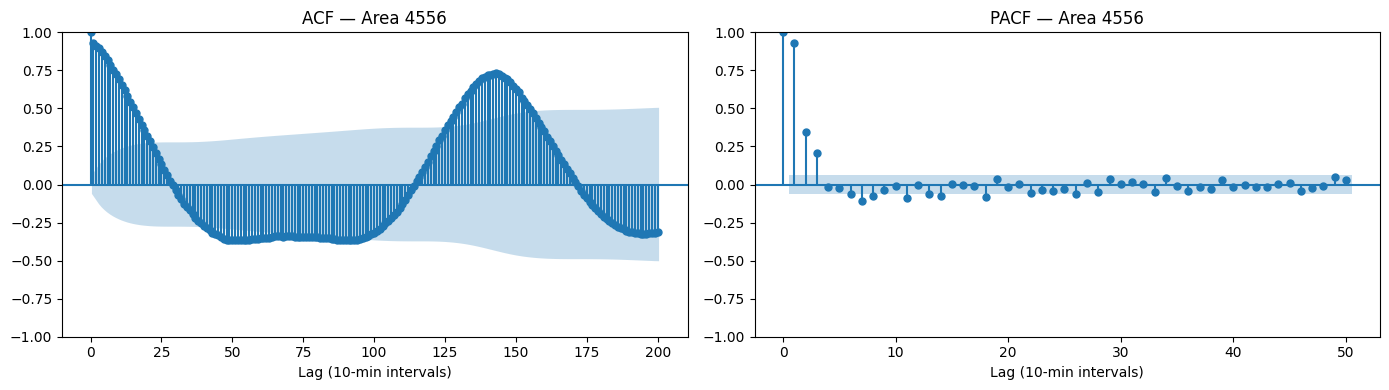

In [ ]:
# CELL 10: Task 2 - ACF & PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # Added import for plot_acf and plot_pacf

for name, s in series.items():
    s1w = s.iloc[:7*PERIOD]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(s1w, lags=200, ax=axes[0], alpha=0.05)
    axes[0].set_title(f'ACF — {name}')
    axes[0].set_xlabel('Lag (10-min intervals)')
    plot_pacf(s1w, lags=50, ax=axes[1], alpha=0.05, method='ywm')
    axes[1].set_title(f'PACF — {name}')
    axes[1].set_xlabel('Lag (10-min intervals)')
    plt.tight_layout()
    safe = name.replace(' ','_').replace('(','').replace(')','')
    plt.savefig(os.path.join(OUTPUT_DIR, f'task2_5_acf_pacf_{safe}.png'), bbox_inches='tight')
    plt.show()

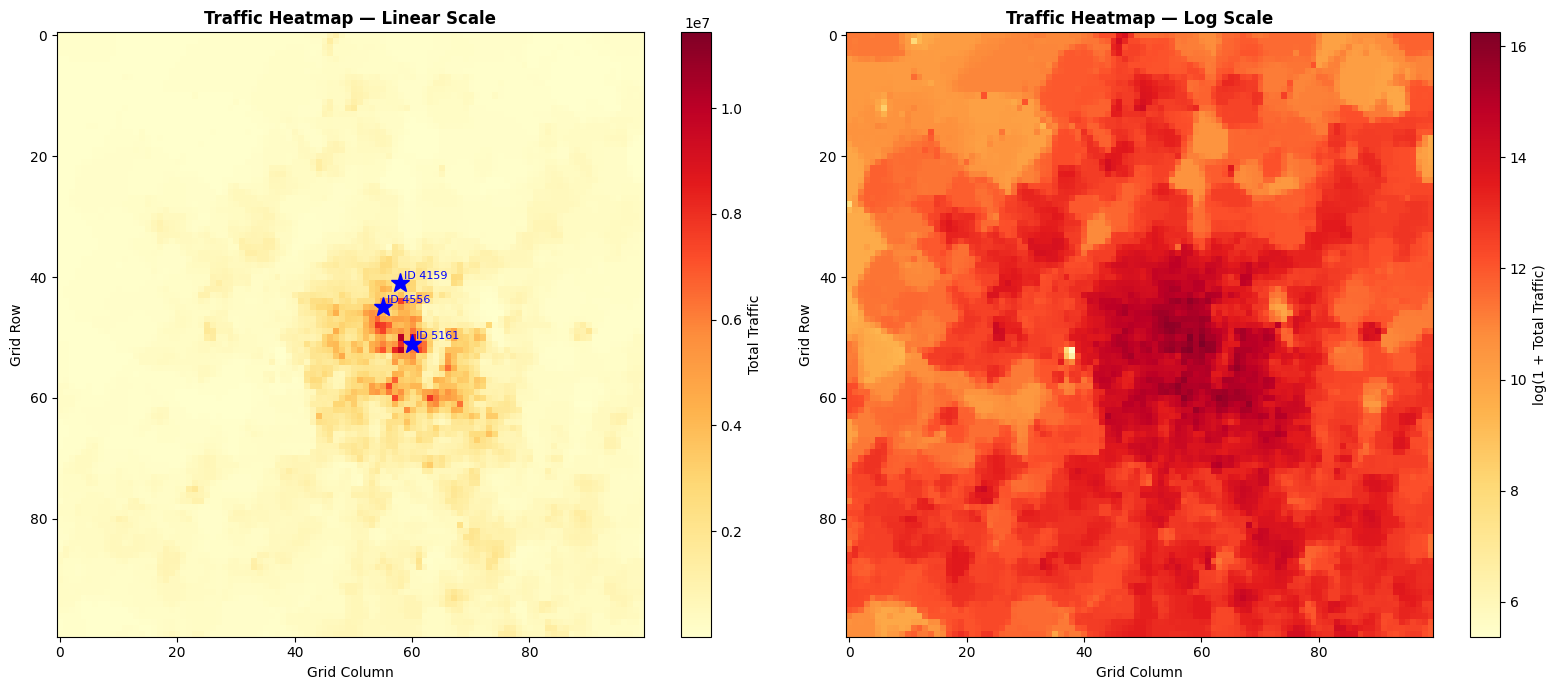

In [ ]:
# CELL 11: Task 2 - Spatial Heatmap
grid = np.zeros((100, 100))
for sq_id, traffic in total_per_area.items():
    r = (int(sq_id) - 1) // 100
    c = (int(sq_id) - 1) % 100
    if 0 <= r < 100 and 0 <= c < 100:
        grid[r, c] = traffic

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
im1 = axes[0].imshow(grid, cmap='YlOrRd', aspect='auto')
axes[0].set_title('Traffic Heatmap — Linear Scale', fontweight='bold')
axes[0].set_xlabel('Grid Column')
axes[0].set_ylabel('Grid Row')
plt.colorbar(im1, ax=axes[0], label='Total Traffic')

for name, aid in AREAS.items():
    r = (int(aid) - 1) // 100
    c = (int(aid) - 1) % 100
    axes[0].plot(c, r, 'b*', markersize=14)
    axes[0].annotate(f'ID {aid}', (c, r), xytext=(3, 3),
                     textcoords='offset points', color='blue', fontsize=8)

im2 = axes[1].imshow(np.log1p(grid), cmap='YlOrRd', aspect='auto')
axes[1].set_title('Traffic Heatmap — Log Scale', fontweight='bold')
axes[1].set_xlabel('Grid Column')
axes[1].set_ylabel('Grid Row')
plt.colorbar(im2, ax=axes[1], label='log(1 + Total Traffic)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'task2_6_heatmap.png'), bbox_inches='tight')
plt.show()

Area 5161 (Highest): 35 anomalies (>5746.6)
Area 4159: 7 anomalies (>848.3)
Area 4556: 67 anomalies (>1278.8)


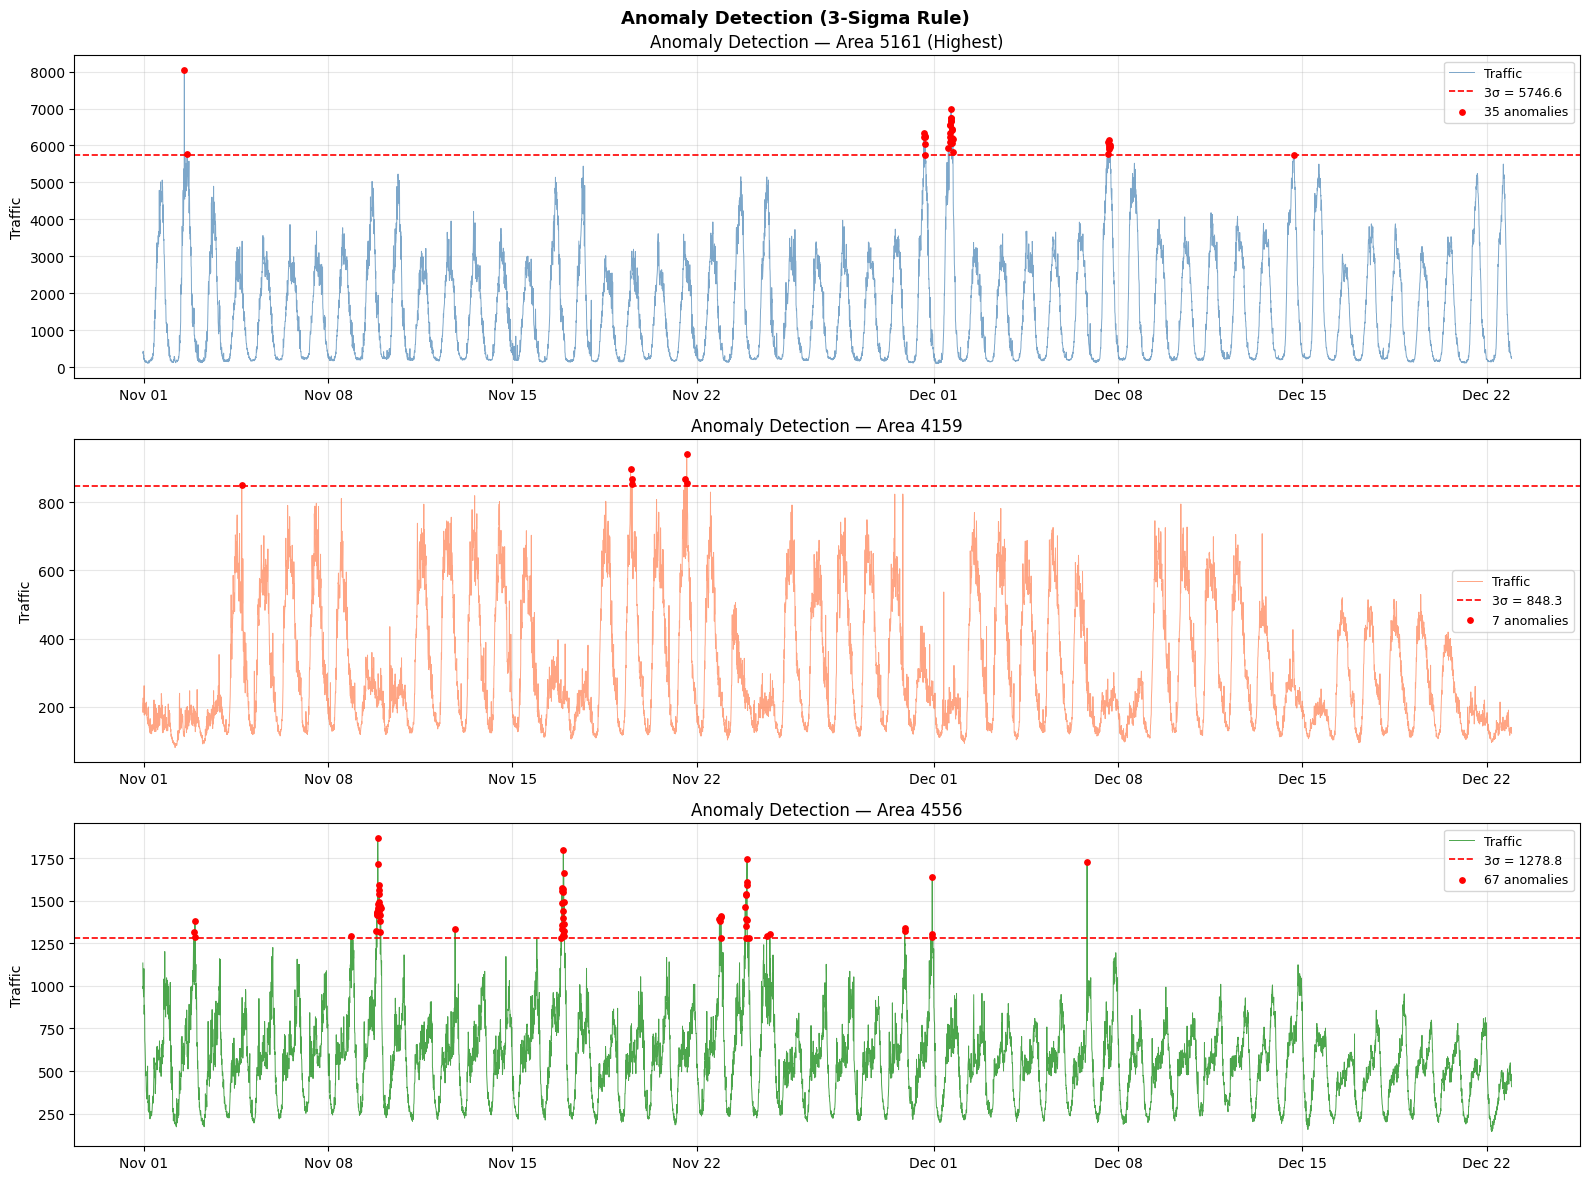

In [ ]:
# CELL 12: Task 2 - Anomaly Detection
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
for ax, (name, s), color in zip(axes, series.items(), COLORS):
    mean, std = s.mean(), s.std()
    threshold  = mean + 3 * std
    anomalies  = s[s > threshold]
    ax.plot(s.index, s.values, color=color, linewidth=0.7, alpha=0.7, label='Traffic')
    ax.axhline(threshold, color='red', linestyle='--', linewidth=1.2,
               label=f'3σ = {threshold:.1f}')
    ax.scatter(anomalies.index, anomalies.values, color='red', s=15, zorder=5,
               label=f'{len(anomalies)} anomalies')
    ax.set_title(f'Anomaly Detection — {name}')
    ax.set_ylabel('Traffic')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    print(f'{name}: {len(anomalies)} anomalies (>{threshold:.1f})')
plt.suptitle('Anomaly Detection (3-Sigma Rule)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'task2_7_anomalies.png'), bbox_inches='tight')
plt.show()

In [ ]:
# CELL 13: Task 3 - Setup for Forecasting
from sklearn.metrics import mean_absolute_error, mean_squared_error # Added imports

TEST_START = pd.Timestamp('2013-12-16')
TEST_END   = pd.Timestamp('2013-12-22 23:59:59')

def get_train_test(s):
    train = s[s.index < TEST_START]
    test  = s[(s.index >= TEST_START) & (s.index <= TEST_END)]
    return train, test

def compute_metrics(actual, predicted):
    actual    = np.array(actual)
    predicted = np.array(predicted)
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mask = actual != 0
    mape = np.mean(np.abs((actual[mask]-predicted[mask])/actual[mask]))*100 if mask.sum()>0 else np.nan
    return {'MAE': mae, 'MAPE': mape, 'RMSE': rmse}

splits = {}
for name, s in series.items():
    train, test = get_train_test(s)
    splits[name] = {'train': train, 'test': test}
    print(f'{name}: train={len(train)} | test={len(test)}')


Area 5161 (Highest): train=6486 | test=1002
Area 4159: train=6486 | test=1002
Area 4556: train=6486 | test=1002


In [ ]:
# CELL 14: Task 3 - SARIMA Model
from sklearn.preprocessing import MinMaxScaler # Added import for MinMaxScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX # Added import for SARIMAX

sarima_results = {}

for name, sp in splits.items():
    print(f'\nFitting SARIMA — {name}...')
    train_h = sp['train'].resample('1h').sum()
    test_h  = sp['test'].resample('1h').sum()

    scaler = MinMaxScaler()
    tr_sc  = scaler.fit_transform(train_h.values.reshape(-1,1)).flatten()

    t0 = time.time()
    model  = SARIMAX(tr_sc, order=(1,0,1), seasonal_order=(1,1,1,24),
                     enforce_stationarity=False, enforce_invertibility=False)
    fitted = model.fit(disp=False)
    train_time = time.time() - t0
    print(f'  Train time: {train_time:.1f}s | AIC: {fitted.aic:.2f}')

    t1 = time.time()
    fc_sc = fitted.forecast(steps=len(test_h))
    infer_time = time.time() - t1

    fc_h = scaler.inverse_transform(fc_sc.reshape(-1,1)).flatten()
    fc_h = np.maximum(fc_h, 0)

    # Upsample hourly → 10-min by distributing evenly
    fc_10 = np.repeat(fc_h / 6, 6)
    act   = sp['test'].values
    n     = min(len(fc_10), len(act))

    m = compute_metrics(act[:n], fc_10[:n])
    m['train_time'] = train_time
    m['infer_time'] = infer_time
    sarima_results[name] = {'preds': fc_10[:n], 'metrics': m}
    print(f'  MAE={m["MAE"]:.4f} | MAPE={m["MAPE"]:.2f}% | RMSE={m["RMSE"]:.4f}')


Fitting SARIMA — Area 5161 (Highest)...
  Train time: 10.4s | AIC: -4122.08
  MAE=324.4198 | MAPE=29.09% | RMSE=487.9086

Fitting SARIMA — Area 4159...
  Train time: 7.2s | AIC: -3176.81
  MAE=76.9665 | MAPE=42.19% | RMSE=121.6505

Fitting SARIMA — Area 4556...
  Train time: 9.8s | AIC: -3370.25
  MAE=119.6074 | MAPE=27.96% | RMSE=150.5750


In [ ]:
# CELL 15: Task 3 - LSTM Model
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def make_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

class LSTMModel(nn.Module):
    def __init__(self, hidden=64, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, layers, batch_first=True, dropout=dropout)
        self.fc   = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:,-1,:]).squeeze()

lstm_results = {}
SEQ_LEN = 144  # 24 hours of history

for name, sp in splits.items():
    print(f'\nTraining LSTM — {name}...')
    scaler   = MinMaxScaler()
    tr_sc    = scaler.fit_transform(sp['train'].values.reshape(-1,1)).flatten()
    X, y     = make_sequences(tr_sc, SEQ_LEN)
    X_t      = torch.tensor(X).unsqueeze(-1)
    y_t      = torch.tensor(y)
    loader   = DataLoader(TensorDataset(X_t, y_t), batch_size=256, shuffle=True)

    model     = LSTMModel().to(DEVICE)
    opt       = torch.optim.Adam(model.parameters(), lr=0.001)
    sched     = torch.optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.5)
    criterion = nn.MSELoss()
    losses    = []

    t0 = time.time()
    for epoch in range(1, 31):
        model.train()
        eloss = 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            eloss += loss.item()
        sched.step()
        avg = eloss / len(loader)
        losses.append(avg)
        if epoch % 5 == 0:
            print(f'  Epoch {epoch:2d}/30 | Loss: {avg:.6f}')
    train_time = time.time() - t0

    # Rolling forecast
    model.eval()
    ctx = list(tr_sc[-SEQ_LEN:])
    ps  = []
    t1  = time.time()
    with torch.no_grad():
        for i in range(len(sp['test'])):
            xi = torch.tensor(ctx[-SEQ_LEN:], dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(DEVICE)
            p  = model(xi).item()
            ps.append(p)
            nv = float(scaler.transform([[sp['test'].values[i]]])[0][0])
            ctx.append(nv)
    infer_time = time.time() - t1

    preds = np.maximum(scaler.inverse_transform(np.array(ps).reshape(-1,1)).flatten(), 0)
    act   = sp['test'].values[:len(preds)]
    m     = compute_metrics(act, preds)
    m['train_time'] = train_time
    m['infer_time'] = infer_time
    lstm_results[name] = {'preds': preds, 'metrics': m, 'losses': losses}
    print(f'  Train: {train_time:.1f}s | MAE={m["MAE"]:.4f} | MAPE={m["MAPE"]:.2f}% | RMSE={m["RMSE"]:.4f}')


Training LSTM — Area 5161 (Highest)...
  Epoch  5/30 | Loss: 0.001773
  Epoch 10/30 | Loss: 0.001337
  Epoch 15/30 | Loss: 0.001221
  Epoch 20/30 | Loss: 0.001161
  Epoch 25/30 | Loss: 0.001128
  Epoch 30/30 | Loss: 0.001097
  Train: 6.7s | MAE=126.1851 | MAPE=12.86% | RMSE=186.2207

Training LSTM — Area 4159...
  Epoch  5/30 | Loss: 0.005161
  Epoch 10/30 | Loss: 0.003824
  Epoch 15/30 | Loss: 0.003636
  Epoch 20/30 | Loss: 0.003385
  Epoch 25/30 | Loss: 0.003224
  Epoch 30/30 | Loss: 0.003185
  Train: 5.8s | MAE=18.8882 | MAPE=8.85% | RMSE=24.2581

Training LSTM — Area 4556...
  Epoch  5/30 | Loss: 0.002608
  Epoch 10/30 | Loss: 0.002283
  Epoch 15/30 | Loss: 0.002214
  Epoch 20/30 | Loss: 0.002183
  Epoch 25/30 | Loss: 0.002130
  Epoch 30/30 | Loss: 0.002115
  Train: 5.7s | MAE=33.2344 | MAPE=8.15% | RMSE=42.5079


In [ ]:
# CELL 16: Task 3 - TCN Model
class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, k, d):
        super().__init__()
        self.pad  = (k-1)*d
        self.conv = nn.Conv1d(in_ch, out_ch, k, padding=self.pad, dilation=d)
    def forward(self, x):
        return self.conv(x)[:,:,:-self.pad] if self.pad > 0 else self.conv(x)

class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k, d, drop=0.2):
        super().__init__()
        self.c1  = CausalConv1d(in_ch, out_ch, k, d)
        self.c2  = CausalConv1d(out_ch, out_ch, k, d)
        self.n1  = nn.BatchNorm1d(out_ch)
        self.n2  = nn.BatchNorm1d(out_ch)
        self.dr  = nn.Dropout(drop)
        self.relu= nn.ReLU()
        self.ds  = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
    def forward(self, x):
        res = self.ds(x) if self.ds else x
        out = self.dr(self.relu(self.n1(self.c1(x))))
        out = self.dr(self.relu(self.n2(self.c2(out))))
        return self.relu(out + res)

class TCNModel(nn.Module):
    def __init__(self, channels=[32,64,64,32], k=3, drop=0.2):
        super().__init__()
        layers, in_ch = [], 1
        for i, ch in enumerate(channels):
            layers.append(TCNBlock(in_ch, ch, k, 2**i, drop))
            in_ch = ch
        self.net = nn.Sequential(*layers)
        self.fc  = nn.Linear(channels[-1], 1)
    def forward(self, x):
        out = self.net(x.transpose(1,2))
        return self.fc(out[:,:,-1]).squeeze()

tcn_results = {}

for name, sp in splits.items():
    print(f'\nTraining TCN — {name}...')
    scaler   = MinMaxScaler()
    tr_sc    = scaler.fit_transform(sp['train'].values.reshape(-1,1)).flatten()
    X, y     = make_sequences(tr_sc, SEQ_LEN)
    X_t      = torch.tensor(X).unsqueeze(-1)
    y_t      = torch.tensor(y)
    loader   = DataLoader(TensorDataset(X_t, y_t), batch_size=256, shuffle=True)

    model     = TCNModel().to(DEVICE)
    opt       = torch.optim.Adam(model.parameters(), lr=0.001)
    sched     = torch.optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.5)
    criterion = nn.MSELoss()
    losses    = []

    t0 = time.time()
    for epoch in range(1, 31):
        model.train()
        eloss = 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            eloss += loss.item()
        sched.step()
        avg = eloss / len(loader)
        losses.append(avg)
        if epoch % 5 == 0:
            print(f'  Epoch {epoch:2d}/30 | Loss: {avg:.6f}')
    train_time = time.time() - t0

    model.eval()
    ctx = list(tr_sc[-SEQ_LEN:])
    ps  = []
    t1  = time.time()
    with torch.no_grad():
        for i in range(len(sp['test'])):
            xi = torch.tensor(ctx[-SEQ_LEN:], dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(DEVICE)
            p  = model(xi).item()
            ps.append(p)
            nv = float(scaler.transform([[sp['test'].values[i]]])[0][0])
            ctx.append(nv)
    infer_time = time.time() - t1

    preds = np.maximum(scaler.inverse_transform(np.array(ps).reshape(-1,1)).flatten(), 0)
    act   = sp['test'].values[:len(preds)]
    m     = compute_metrics(act, preds)
    m['train_time'] = train_time
    m['infer_time'] = infer_time
    tcn_results[name] = {'preds': preds, 'metrics': m, 'losses': losses}
    print(f'  Train: {train_time:.1f}s | MAE={m["MAE"]:.4f} | MAPE={m["MAPE"]:.2f}% | RMSE={m["RMSE"]:.4f}')


Training TCN — Area 5161 (Highest)...
  Epoch  5/30 | Loss: 0.004619
  Epoch 10/30 | Loss: 0.002778
  Epoch 15/30 | Loss: 0.002288
  Epoch 20/30 | Loss: 0.001857
  Epoch 25/30 | Loss: 0.001864
  Epoch 30/30 | Loss: 0.001663
  Train: 14.2s | MAE=125.9382 | MAPE=15.05% | RMSE=189.0882

Training TCN — Area 4159...
  Epoch  5/30 | Loss: 0.007728
  Epoch 10/30 | Loss: 0.004868
  Epoch 15/30 | Loss: 0.004233
  Epoch 20/30 | Loss: 0.003882
  Epoch 25/30 | Loss: 0.003715
  Epoch 30/30 | Loss: 0.003612
  Train: 13.9s | MAE=19.2605 | MAPE=8.00% | RMSE=26.4911

Training TCN — Area 4556...
  Epoch  5/30 | Loss: 0.006970
  Epoch 10/30 | Loss: 0.003838
  Epoch 15/30 | Loss: 0.003464
  Epoch 20/30 | Loss: 0.002958
  Epoch 25/30 | Loss: 0.002876
  Epoch 30/30 | Loss: 0.002800
  Train: 13.8s | MAE=31.7314 | MAPE=7.35% | RMSE=41.8592


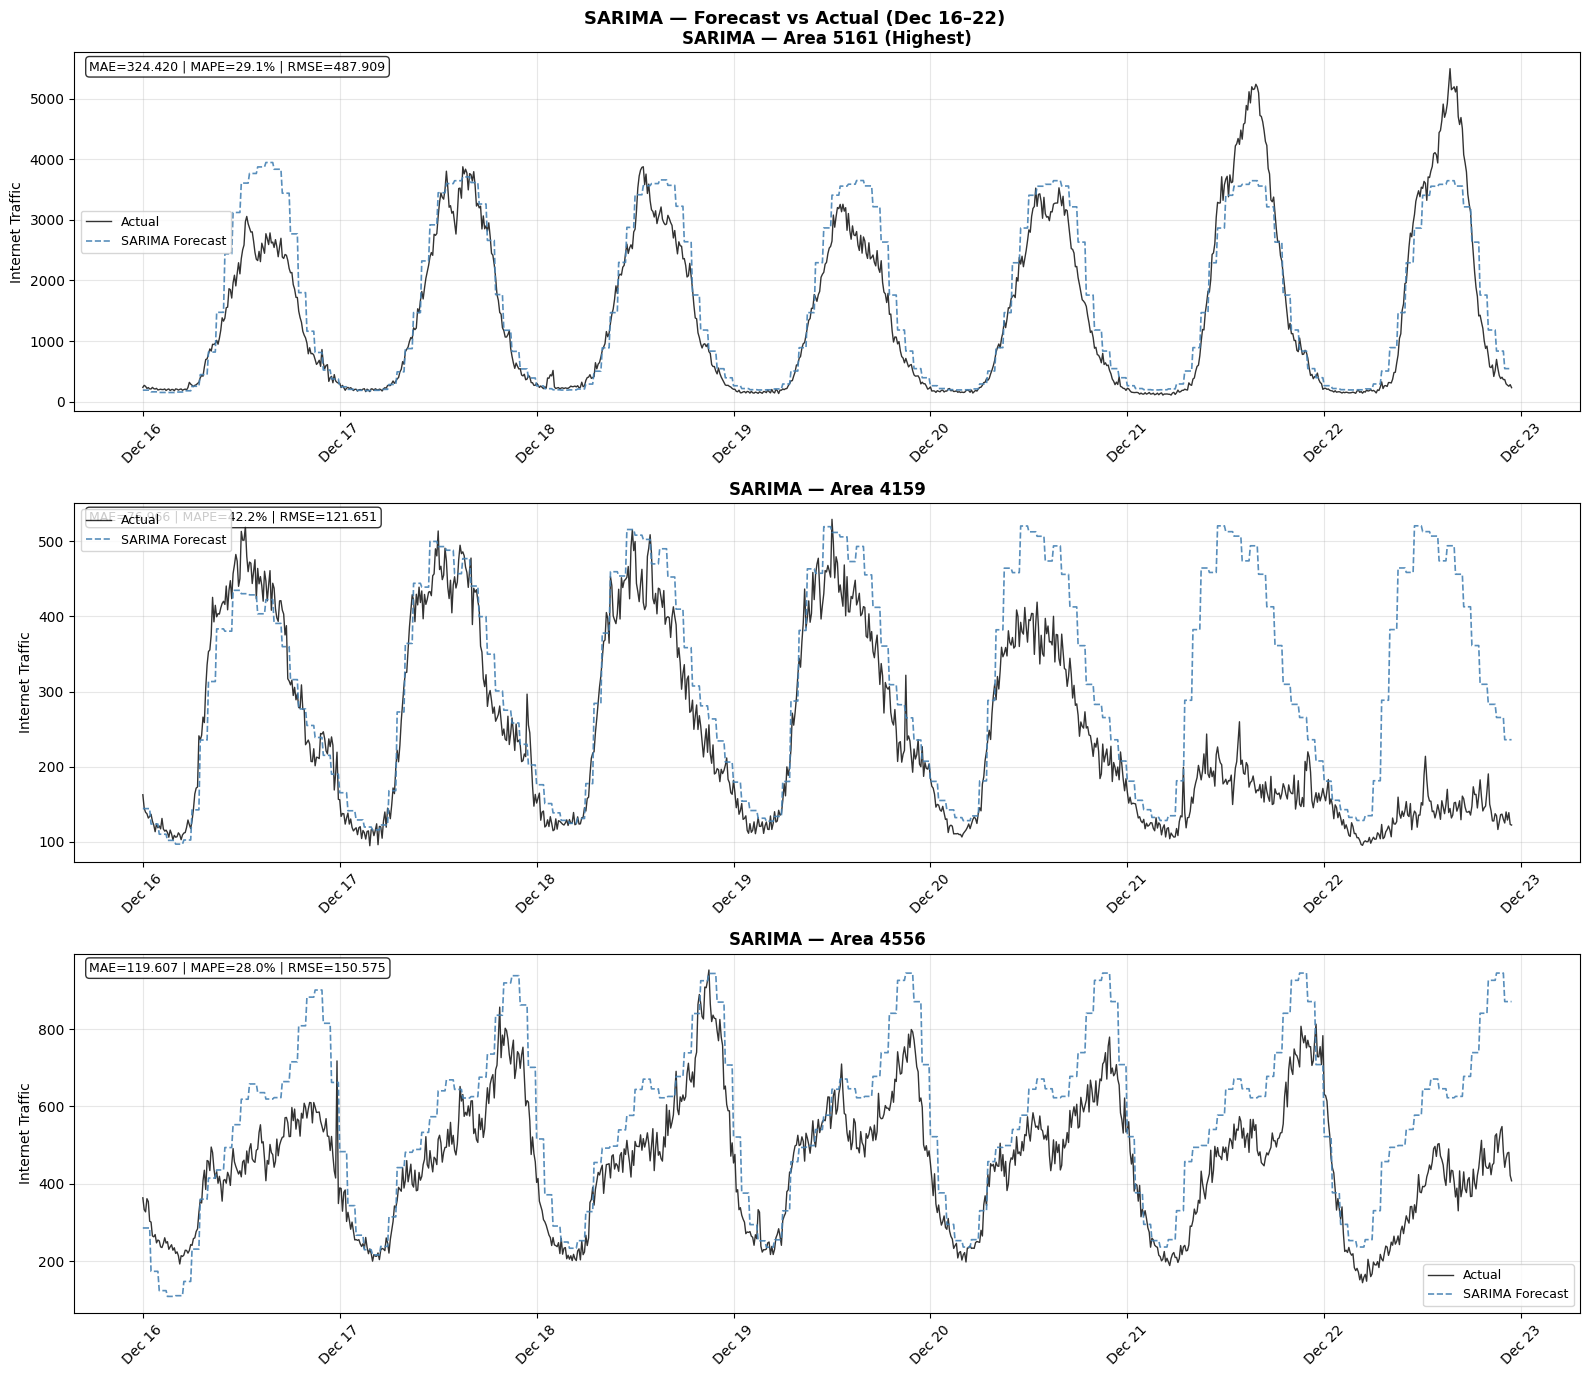

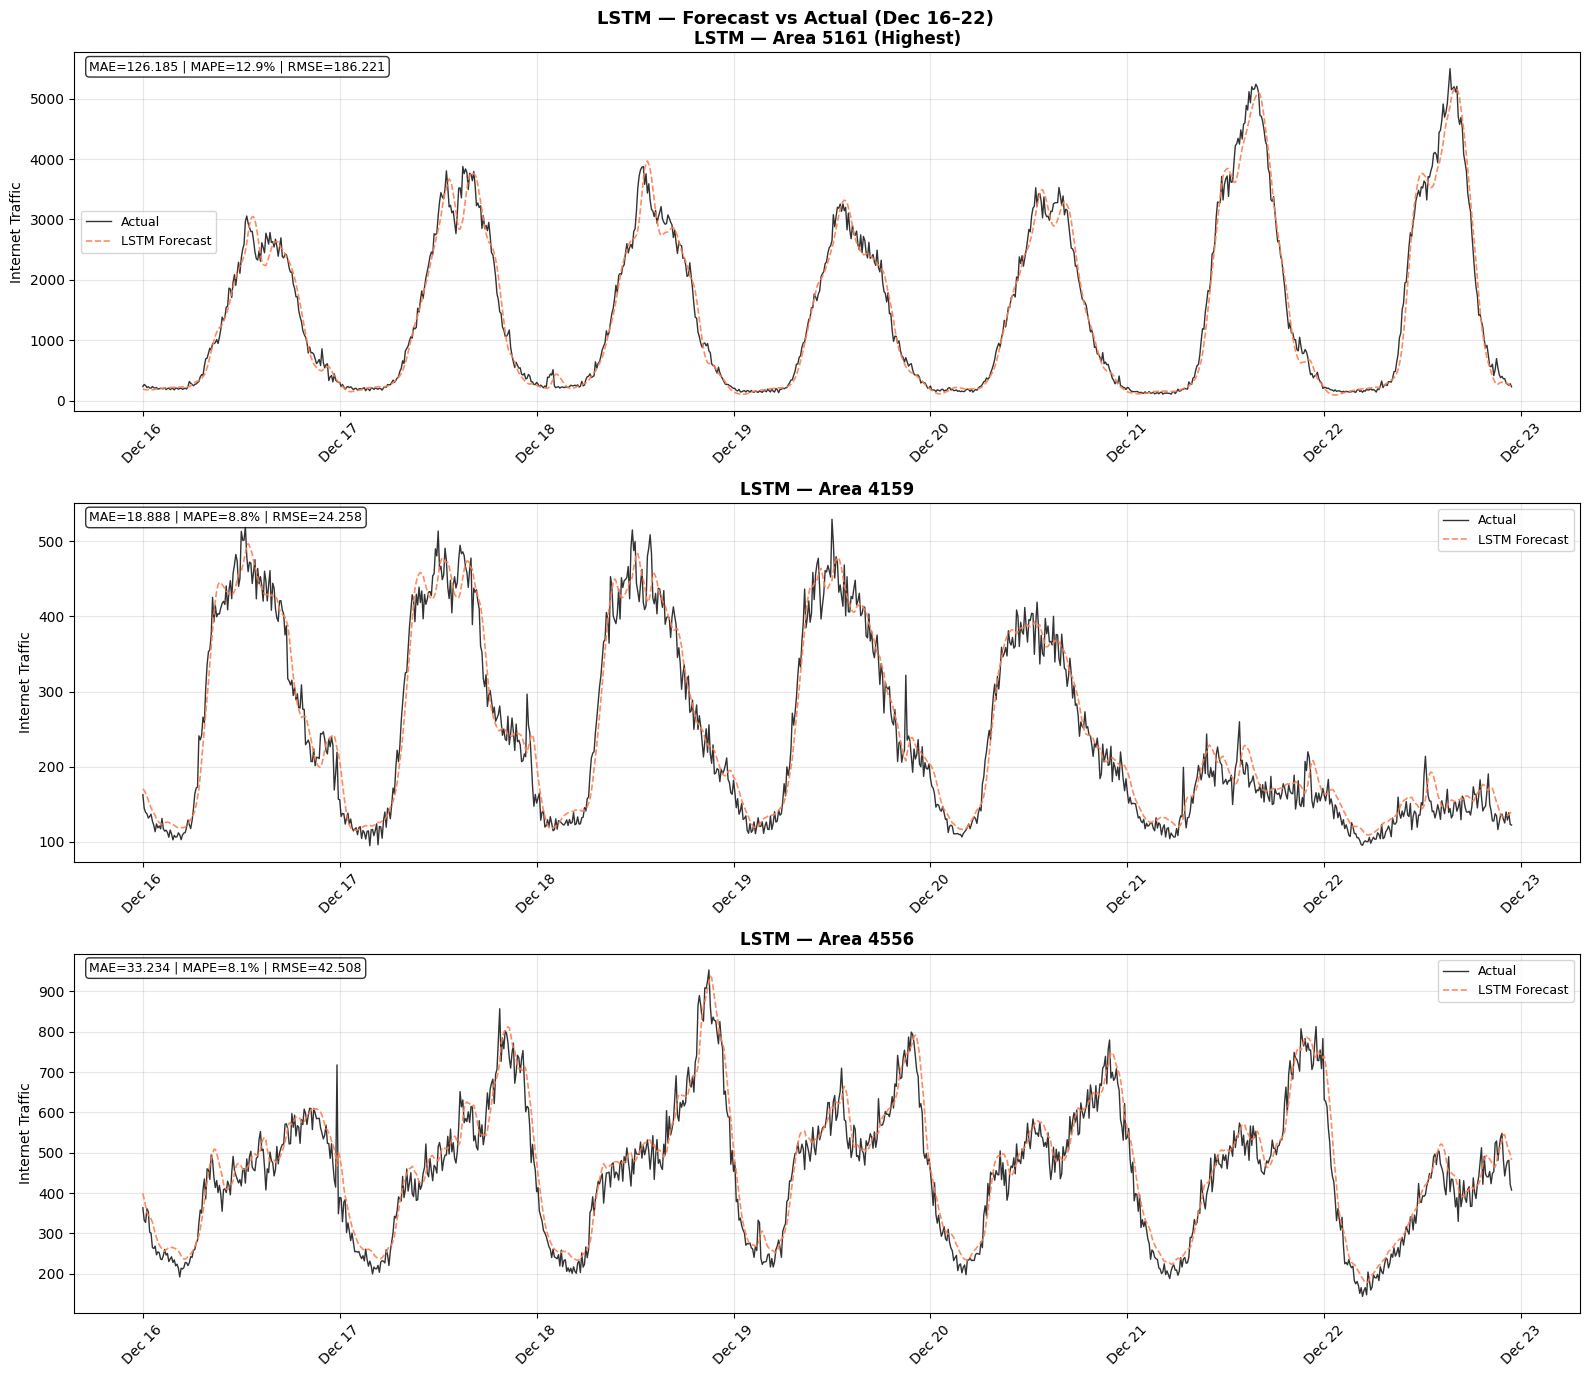

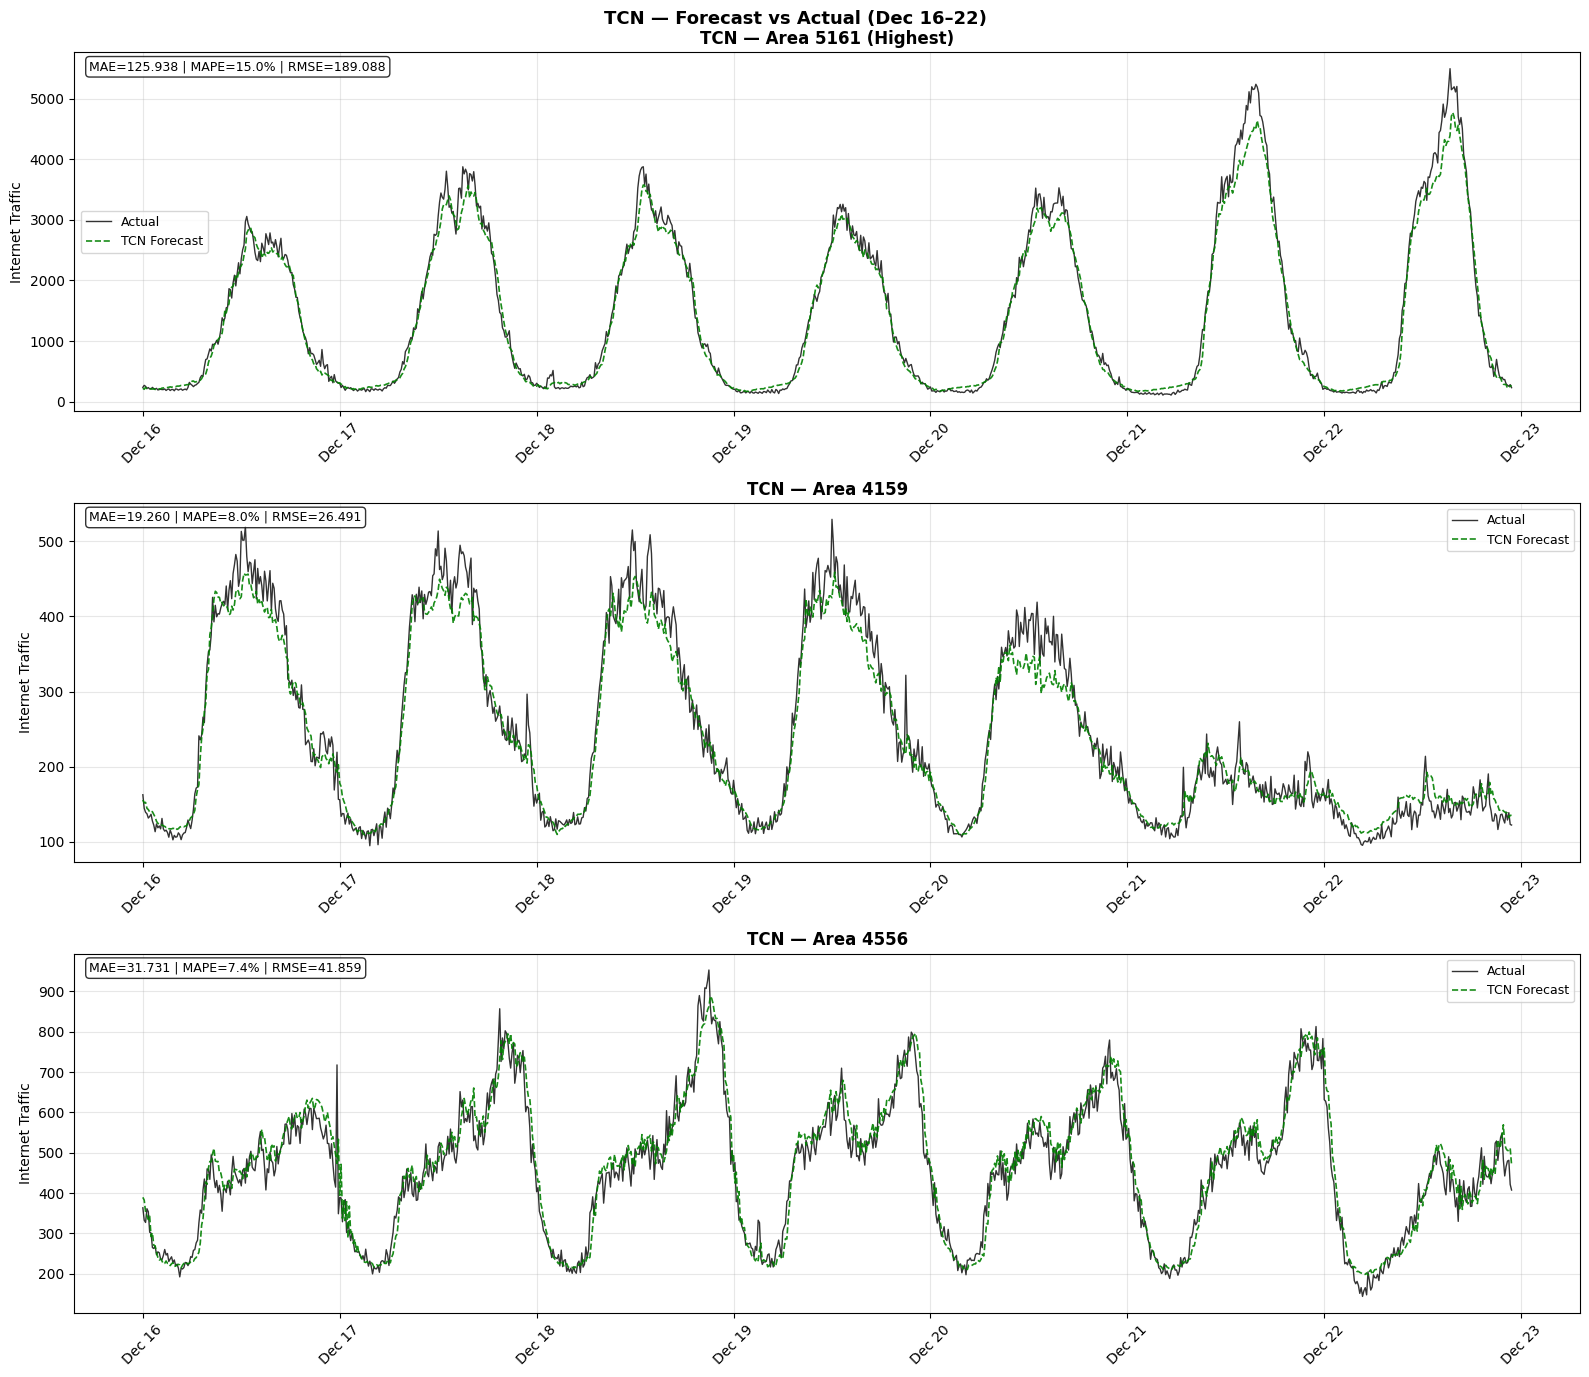

In [ ]:
# CELL 17: Task 3 - Prediction Plots
ALL_MODELS = [
    ('SARIMA', sarima_results, 'steelblue'),
    ('LSTM',   lstm_results,   'coral'),
    ('TCN',    tcn_results,    'green'),
]

for model_name, results, color in ALL_MODELS:
    fig, axes = plt.subplots(3, 1, figsize=(16, 14))
    for ax, (area_name, sp) in zip(axes, splits.items()):
        test  = sp['test']
        preds = results[area_name]['preds']
        pidx  = test.index[:len(preds)]
        ax.plot(test.index, test.values, color='black', linewidth=1, label='Actual', alpha=0.8)
        ax.plot(pidx, preds, color=color, linewidth=1.2, linestyle='--',
                label=f'{model_name} Forecast', alpha=0.9)
        m = results[area_name]['metrics']
        ax.set_title(f'{model_name} — {area_name}', fontweight='bold')
        ax.set_ylabel('Internet Traffic')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        ax.xaxis.set_major_locator(mdates.DayLocator())
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
        ax.annotate(f"MAE={m['MAE']:.3f} | MAPE={m['MAPE']:.1f}% | RMSE={m['RMSE']:.3f}",
                    xy=(0.01,0.95), xycoords='axes fraction', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    plt.suptitle(f'{model_name} — Forecast vs Actual (Dec 16–22)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'task3_forecast_{model_name}.png'), bbox_inches='tight')
    plt.show()

In [ ]:
# CELL 18: Task 3 - Performance Tables
print('=' * 70)
for area_name in splits.keys():
    rows = []
    for mname, res, _ in ALL_MODELS:
        m = res[area_name]['metrics']
        rows.append({
            'Model': mname,
            'MAE':          round(m['MAE'],  4),
            'MAPE (%)':     round(m['MAPE'], 2),
            'RMSE':         round(m['RMSE'], 4),
            'Train (s)':    round(m['train_time'], 1),
            'Infer (s)':    round(m['infer_time'], 3),
        })
    df_t = pd.DataFrame(rows).set_index('Model')
    print(f'\n=== {area_name} ===')
    print(df_t.to_string())
    df_t.to_csv(os.path.join(OUTPUT_DIR, f'metrics_{area_name[:10].replace(" ", "_")}.csv'))
print('\nTables saved!')


=== Area 5161 (Highest) ===
             MAE  MAPE (%)      RMSE  Train (s)  Infer (s)
Model                                                     
SARIMA  324.4198     29.09  487.9086       10.4      0.014
LSTM    126.1851     12.86  186.2207        6.7      0.738
TCN     125.9382     15.05  189.0882       14.2      2.251

=== Area 4159 ===
            MAE  MAPE (%)      RMSE  Train (s)  Infer (s)
Model                                                    
SARIMA  76.9665     42.19  121.6505        7.2      0.014
LSTM    18.8882      8.85   24.2581        5.8      0.897
TCN     19.2605      8.00   26.4911       13.9      2.229

=== Area 4556 ===
             MAE  MAPE (%)      RMSE  Train (s)  Infer (s)
Model                                                     
SARIMA  119.6074     27.96  150.5750        9.8      0.013
LSTM     33.2344      8.15   42.5079        5.7      0.705
TCN      31.7314      7.35   41.8592       13.8      2.150

Tables saved!


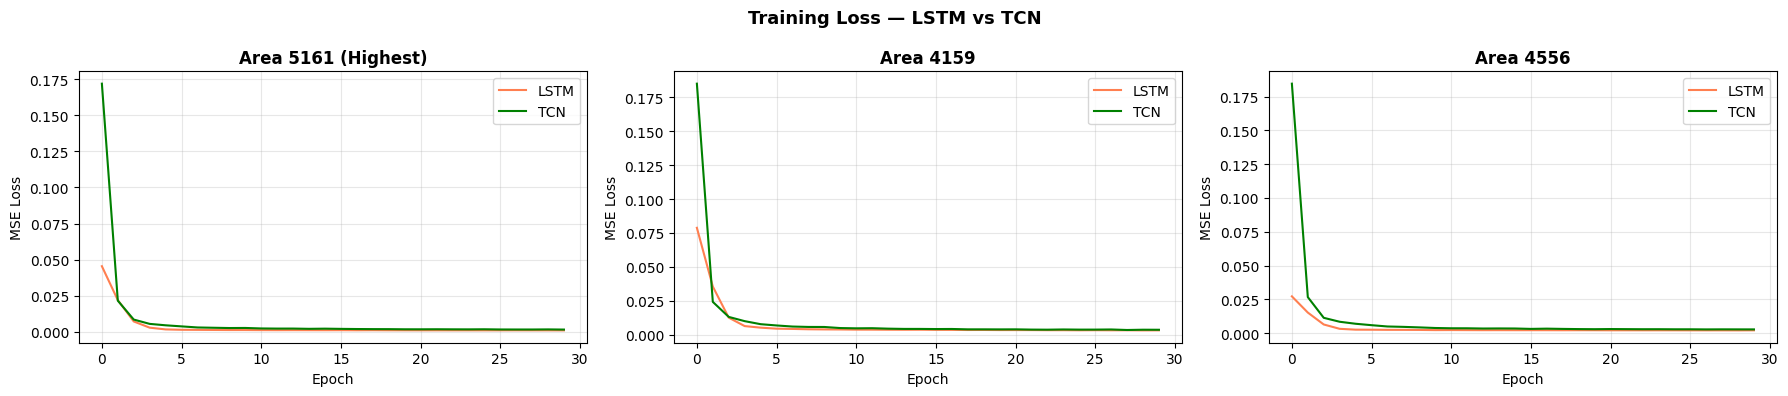

In [ ]:
# CELL 19: Task 3 - Training Loss Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (area_name, _) in zip(axes, splits.items()):
    ax.plot(lstm_results[area_name]['losses'], label='LSTM',  color='coral')
    ax.plot(tcn_results[area_name]['losses'],  label='TCN',   color='green')
    ax.set_title(f'{area_name}', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('Training Loss — LSTM vs TCN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'task3_loss_curves.png'), bbox_inches='tight')
plt.show()

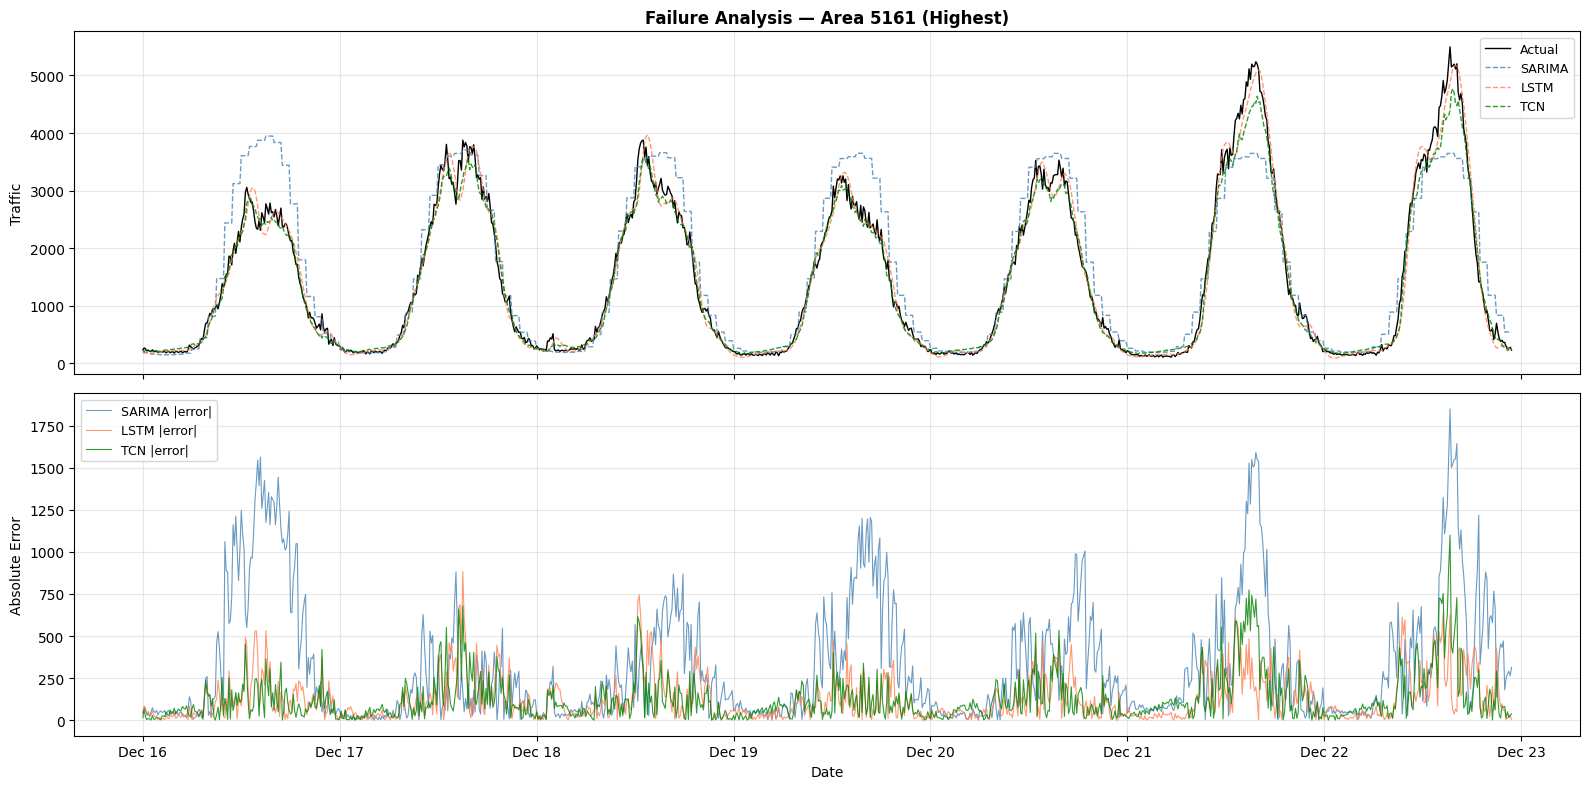

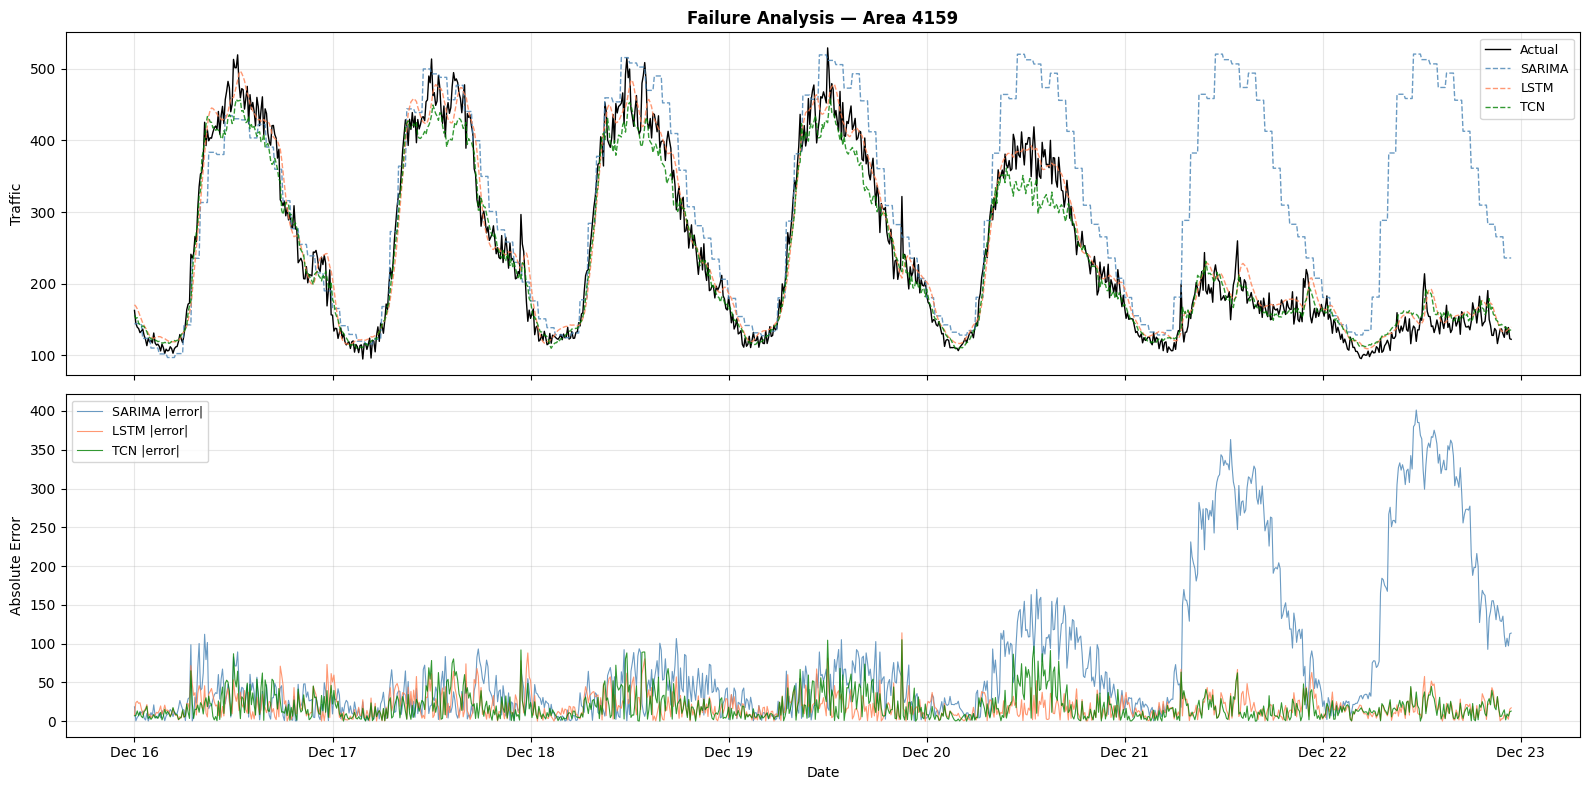

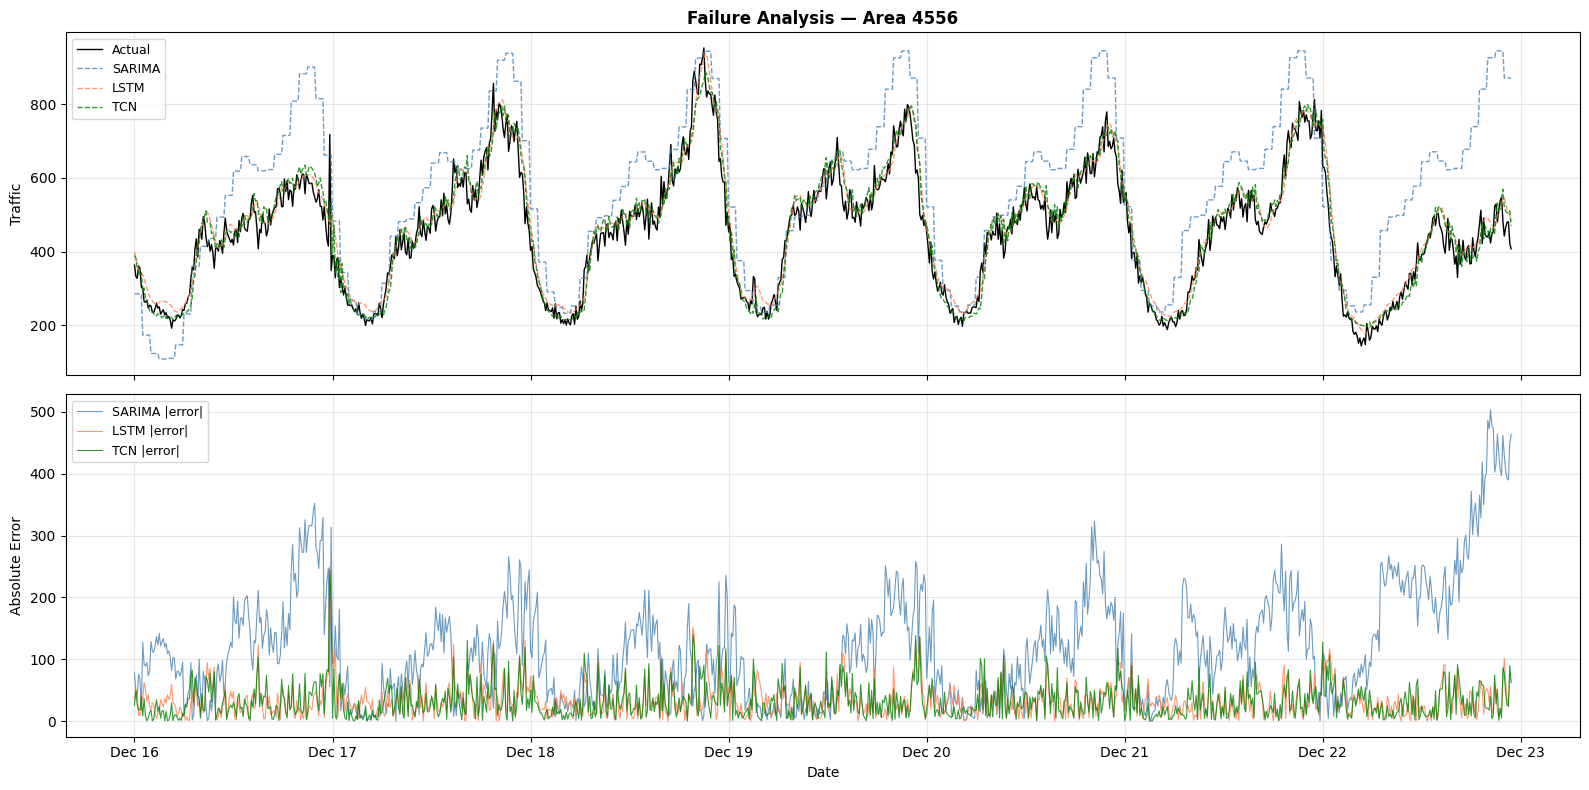

In [ ]:
# CELL 20: Task 3 - Failure Analysis
for area_name, sp in splits.items():
    test = sp['test']
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    axes[0].plot(test.index, test.values, color='black', linewidth=1, label='Actual')
    for mname, res, color in ALL_MODELS:
        p = res[area_name]['preds']
        axes[0].plot(test.index[:len(p)], p, color=color, linewidth=1,
                     linestyle='--', alpha=0.8, label=mname)
    axes[0].set_title(f'Failure Analysis — {area_name}', fontweight='bold')
    axes[0].set_ylabel('Traffic')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)
    for mname, res, color in ALL_MODELS:
        p   = res[area_name]['preds']
        err = np.abs(test.values[:len(p)] - p)
        axes[1].plot(test.index[:len(p)], err, color=color, linewidth=0.8,
                     alpha=0.8, label=f'{mname} |error|')
    axes[1].set_ylabel('Absolute Error')
    axes[1].set_xlabel('Date')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.tight_layout()
    safe = area_name.replace(' ','_').replace('(','').replace(')','')
    plt.savefig(os.path.join(OUTPUT_DIR, f'task3_failure_{safe}.png'), bbox_inches='tight')
    plt.show()

In [ ]:
# CELL 21: Final Summary
print('=' * 60)
print('ALL TASKS COMPLETE!')
print('=' * 60)
print('Outputs saved to:', OUTPUT_DIR)
print()
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1024
    print(f'  {f:50s} {size:8.1f} KB')

ALL TASKS COMPLETE!
Outputs saved to: /content/drive/MyDrive/milan_outputs/

  metrics_Area_4159.csv                                   0.2 KB
  metrics_Area_4556.csv                                   0.2 KB
  metrics_Area_5161_.csv                                  0.2 KB
  milan_telecom.parquet                              799962.4 KB
  task2_1_pdf.png                                        36.5 KB
  task2_2_timeseries.png                                268.1 KB
  task2_3_stationarity.png                              313.3 KB
  task2_4_decomp_Area_4159.png                          266.9 KB
  task2_4_decomp_Area_4556.png                          283.6 KB
  task2_4_decomp_Area_5161_Highest.png                  241.1 KB
  task2_5_acf_pacf_Area_4159.png                         34.6 KB
  task2_5_acf_pacf_Area_4556.png                         35.1 KB
  task2_5_acf_pacf_Area_5161_Highest.png                 40.1 KB
  task2_6_heatmap.png                                    82.8 KB
  task2_7_ano